# predicting energy consumption of waste water treatment plant

## preprocessing

In [2]:
import numpy as np
import pandas as pd 
df = pd.read_csv('Data-Melbourne_F_fixed.csv')
df.head()

,Unnamed: 0,Average Outflow,Average Inflow,Energy Consumption,Ammonia,Biological Oxygen Demand,Chemical Oxygen Demand,Total Nitrogen,Average Temperature,Maximum temperature,Minimum temperature,Atmospheric pressure,Average humidity,Total rainfall,Average visibility,Average wind speed,Maximum wind speed,Year,Month,Day
0,0,2.941,2.589,175856.0,27.0,365.0,730.0,60.378,19.3,25.1,12.6,0.0,56.0,1.52,10.0,26.9,53.5,2014.0,1.0,1.0
1,1,2.936,2.961,181624.0,25.0,370.0,740.0,60.026,17.1,23.6,12.3,0.0,63.0,0.00,10.0,14.4,27.8,2014.0,1.0,2.0
2,2,2.928,3.225,202016.0,42.0,418.0,836.0,64.522,16.8,27.2,8.8,0.0,47.0,0.25,10.0,31.9,61.1,2014.0,1.0,5.0
3,3,2.928,3.354,207547.0,36.0,430.0,850.0,63.000,14.6,19.9,11.1,0.0,49.0,0.00,10.0,27.0,38.9,2014.0,1.0,6.0
4,4,2.917,3.794,202824.0,46.0,508.0,1016.0,65.590,13.4,19.1,8.0,0.0,65.0,0.00,10.0,20.6,35.2,2014.0,1.0,7.0


In [3]:
# 1. Remove redundant 'Unnamed: 0' column
df_clean = df.drop(columns=['Unnamed: 0'])

# 2. Move 'Energy Consumption' column to the end (target variable)
target = df_clean.pop('Energy Consumption')
df_clean['Energy Consumption'] = target

# 3. Check for NaN values
nan_info = df_clean.isna().sum()

# Print NaN summary (only columns with NaNs will show)
print("\nColumns with NaN values:")
print(nan_info[nan_info > 0])


Columns with NaN values:
Series([], dtype: int64)


In [4]:
df_clean.head()

,Average Outflow,Average Inflow,Ammonia,Biological Oxygen Demand,Chemical Oxygen Demand,Total Nitrogen,Average Temperature,Maximum temperature,Minimum temperature,Atmospheric pressure,Average humidity,Total rainfall,Average visibility,Average wind speed,Maximum wind speed,Year,Month,Day,Energy Consumption
0,2.941,2.589,27.0,365.0,730.0,60.378,19.3,25.1,12.6,0.0,56.0,1.52,10.0,26.9,53.5,2014.0,1.0,1.0,175856.0
1,2.936,2.961,25.0,370.0,740.0,60.026,17.1,23.6,12.3,0.0,63.0,0.00,10.0,14.4,27.8,2014.0,1.0,2.0,181624.0
2,2.928,3.225,42.0,418.0,836.0,64.522,16.8,27.2,8.8,0.0,47.0,0.25,10.0,31.9,61.1,2014.0,1.0,5.0,202016.0
3,2.928,3.354,36.0,430.0,850.0,63.000,14.6,19.9,11.1,0.0,49.0,0.00,10.0,27.0,38.9,2014.0,1.0,6.0,207547.0
4,2.917,3.794,46.0,508.0,1016.0,65.590,13.4,19.1,8.0,0.0,65.0,0.00,10.0,20.6,35.2,2014.0,1.0,7.0,202824.0


In [5]:
df_clean.shape

(1382, 19)

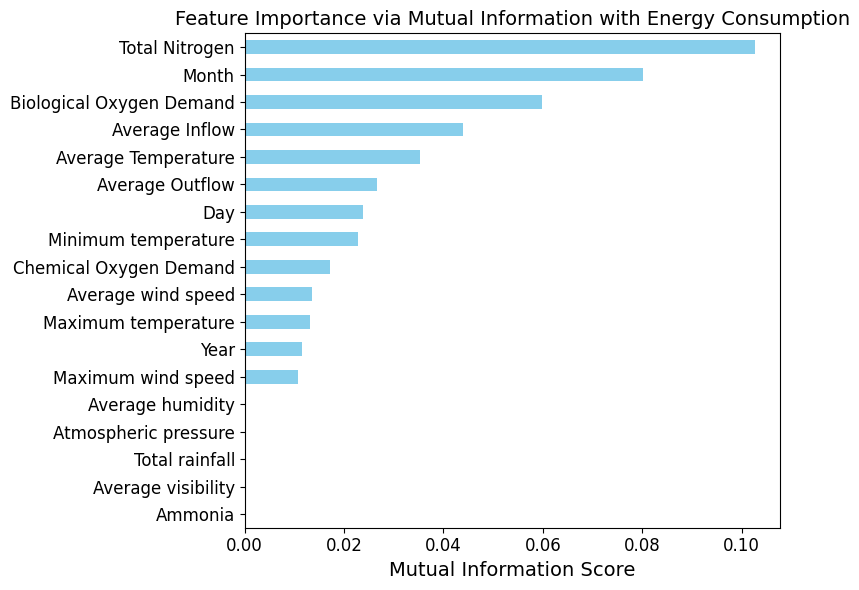

In [6]:
# mutual information
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import pandas as pd

# Separate features and target
X = df_clean.drop(columns=['Energy Consumption'])
y = df_clean['Energy Consumption']

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y, random_state=0)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

# Plot horizontal bar chart (highest MI on top)
plt.figure(figsize=(8, 6))
ax = mi_series.plot(kind='barh', color='skyblue')

# Increase font size for label and ticks
plt.xlabel("Mutual Information Score", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title("Feature Importance via Mutual Information with Energy Consumption", fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
# feature selection

from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Separate features and target
X = df_clean.drop(columns=['Energy Consumption'])
y = df_clean['Energy Consumption']

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y, random_state=0)
mi_series = pd.Series(mi_scores, index=X.columns)

# Filter out features with 0 MI
features_to_keep = mi_series[mi_series > 0].index
df_final = df_clean[features_to_keep.tolist() + ['Energy Consumption']]

# Show new shape and head
print("New shape after removing zero MI features:", df_final.shape)
df_final.head()

New shape after removing zero MI features: (1382, 14)


,Average Outflow,Average Inflow,Biological Oxygen Demand,Chemical Oxygen Demand,Total Nitrogen,Average Temperature,Maximum temperature,Minimum temperature,Average wind speed,Maximum wind speed,Year,Month,Day,Energy Consumption
0,2.941,2.589,365.0,730.0,60.378,19.3,25.1,12.6,26.9,53.5,2014.0,1.0,1.0,175856.0
1,2.936,2.961,370.0,740.0,60.026,17.1,23.6,12.3,14.4,27.8,2014.0,1.0,2.0,181624.0
2,2.928,3.225,418.0,836.0,64.522,16.8,27.2,8.8,31.9,61.1,2014.0,1.0,5.0,202016.0
3,2.928,3.354,430.0,850.0,63.000,14.6,19.9,11.1,27.0,38.9,2014.0,1.0,6.0,207547.0
4,2.917,3.794,508.0,1016.0,65.590,13.4,19.1,8.0,20.6,35.2,2014.0,1.0,7.0,202824.0


In [8]:
# converting energy to mwh instead of kwh
df_final["Energy Consumption (MWh)"] = df_final["Energy Consumption"] / 1000
df_final.head()

/var/folders/4h/gs1k_4jd57q1qn2qphzx45l40000gn/T/ipykernel_48055/3551085457.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Energy Consumption (MWh)"] = df_final["Energy Consumption"] / 1000


,Average Outflow,Average Inflow,Biological Oxygen Demand,Chemical Oxygen Demand,Total Nitrogen,Average Temperature,Maximum temperature,Minimum temperature,Average wind speed,Maximum wind speed,Year,Month,Day,Energy Consumption,Energy Consumption (MWh)
0,2.941,2.589,365.0,730.0,60.378,19.3,25.1,12.6,26.9,53.5,2014.0,1.0,1.0,175856.0,175.856
1,2.936,2.961,370.0,740.0,60.026,17.1,23.6,12.3,14.4,27.8,2014.0,1.0,2.0,181624.0,181.624
2,2.928,3.225,418.0,836.0,64.522,16.8,27.2,8.8,31.9,61.1,2014.0,1.0,5.0,202016.0,202.016
3,2.928,3.354,430.0,850.0,63.000,14.6,19.9,11.1,27.0,38.9,2014.0,1.0,6.0,207547.0,207.547
4,2.917,3.794,508.0,1016.0,65.590,13.4,19.1,8.0,20.6,35.2,2014.0,1.0,7.0,202824.0,202.824


In [9]:
df_final.head()

,Average Outflow,Average Inflow,Biological Oxygen Demand,Chemical Oxygen Demand,Total Nitrogen,Average Temperature,Maximum temperature,Minimum temperature,Average wind speed,Maximum wind speed,Year,Month,Day,Energy Consumption,Energy Consumption (MWh)
0,2.941,2.589,365.0,730.0,60.378,19.3,25.1,12.6,26.9,53.5,2014.0,1.0,1.0,175856.0,175.856
1,2.936,2.961,370.0,740.0,60.026,17.1,23.6,12.3,14.4,27.8,2014.0,1.0,2.0,181624.0,181.624
2,2.928,3.225,418.0,836.0,64.522,16.8,27.2,8.8,31.9,61.1,2014.0,1.0,5.0,202016.0,202.016
3,2.928,3.354,430.0,850.0,63.000,14.6,19.9,11.1,27.0,38.9,2014.0,1.0,6.0,207547.0,207.547
4,2.917,3.794,508.0,1016.0,65.590,13.4,19.1,8.0,20.6,35.2,2014.0,1.0,7.0,202824.0,202.824


In [10]:
# remove energy consimption since we have mwh
df_final = df_final.drop(columns=["Energy Consumption"])

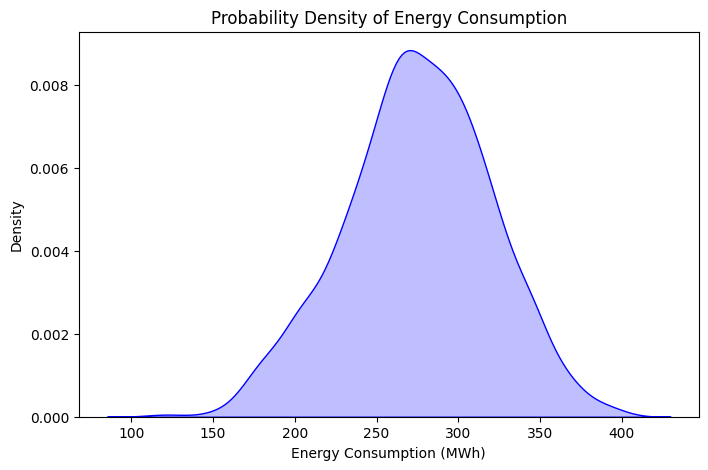

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df_final["Energy Consumption (MWh)"], fill=True, color="blue")
plt.xlabel("Energy Consumption (MWh)")
plt.ylabel("Density")
plt.title("Probability Density of Energy Consumption")
plt.show()

In [12]:
energy_min = df_final["Energy Consumption (MWh)"].min()
energy_max = df_final["Energy Consumption (MWh)"].max()

print(f"Energy Consumption range: {energy_min} – {energy_max}")

Energy Consumption range: 116.638 – 398.328


In [13]:
df_final.head()

,Average Outflow,Average Inflow,Biological Oxygen Demand,Chemical Oxygen Demand,Total Nitrogen,Average Temperature,Maximum temperature,Minimum temperature,Average wind speed,Maximum wind speed,Year,Month,Day,Energy Consumption (MWh)
0,2.941,2.589,365.0,730.0,60.378,19.3,25.1,12.6,26.9,53.5,2014.0,1.0,1.0,175.856
1,2.936,2.961,370.0,740.0,60.026,17.1,23.6,12.3,14.4,27.8,2014.0,1.0,2.0,181.624
2,2.928,3.225,418.0,836.0,64.522,16.8,27.2,8.8,31.9,61.1,2014.0,1.0,5.0,202.016
3,2.928,3.354,430.0,850.0,63.000,14.6,19.9,11.1,27.0,38.9,2014.0,1.0,6.0,207.547
4,2.917,3.794,508.0,1016.0,65.590,13.4,19.1,8.0,20.6,35.2,2014.0,1.0,7.0,202.824


In [14]:
df_final.shape

(1382, 14)

## Random forest

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Assuming df_final is already loaded
# Last column is the target
X = df_final.iloc[:, :-1].values
y = df_final.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Random Forest model
rf = RandomForestRegressor(
    n_estimators=500,   # more trees for stability
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Performance metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # in percentage

print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

R² Score: 0.3478
MSE: 1242.2839
RMSE: 35.2460
MAE: 26.6309
MAPE: 10.38%


## svm

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Assuming df_final is already loaded
# Last column is the target
X = df_final.iloc[:, :-1].values
y = df_final.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for SVM)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Also scale target for stability (optional but recommended)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# Build Support Vector Regression model
svm = SVR(kernel='rbf', C=100, epsilon=0.1)  # common starting params
svm.fit(X_train_scaled, y_train_scaled)

# Predictions (inverse transform to original scale)
y_pred_scaled = svm.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Performance metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # in percentage

print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

R² Score: -0.3896
MSE: 2646.8496
RMSE: 51.4475
MAE: 38.6976
MAPE: 14.83%


## ANIFS - zero order

In [17]:
import numpy as np  
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  
from sklearn.cluster import KMeans  
import matplotlib.pyplot as plt  

class ANFIS:
    def __init__(self, n_clusters, X): # X input data shape (N, F)
        self.n_clusters, self.n_features = n_clusters, X.shape[1]  # set sizes
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)  # init clusters
        self.centers = kmeans.cluster_centers_  # center shape (K, F)
        labels      = kmeans.labels_               # (N,)
        diffs = X[:, None, :] - self.centers[None, :, :] # N, K, F)
        one_hot = np.eye(self.n_clusters, dtype=bool)[labels]  # (N, K)
        mask = (~one_hot[:, :, None]).repeat(self.n_features, axis=2) # (N,K,F)
        raw_stds = np.ma.array(diffs, mask=mask).std(axis=0).filled(0)
        self.stds = np.maximum(raw_stds, 1)


    def _membership(self, X):
        diffs = X[:, None, :] - self.centers[None, :, :]  # broadcast diff
        sq = diffs**2 / (2 * self.stds[None, :, :]**2)  # Distance
        M = np.exp(-sq.sum(axis=2))  # sum over features resize-> (N,K)
        return M / M.sum(axis=1, keepdims=True)  # normalize memberships

    def fit(self, X, y, Xv, yv, epochs=100, lr=1e-4, patience=20):
        N = X.shape[0]
        best_mse, wait = np.inf, 0  # early-stopping trackers
        for ep in range(epochs):
            M = self._membership(X)  # (N,K)
            theta = np.linalg.lstsq(M, y, rcond=None)[0]  # solve Θ = argmin||MΘ−y||
            self.w = theta  # consequent weights only
            y_pred = M @ self.w  # model output
            mse = mean_squared_error(y, y_pred)  # train MSE

            Mv = self._membership(Xv)  # val memberships
            val_mse = mean_squared_error(yv, Mv @ self.w)  # val MSE
            print(f"Epoch {ep+1}, Train MSE: {mse:.4f}, Val MSE: {val_mse:.4f}", flush=True)

            err = (y - y_pred)[:, None, None]  # (N,1,1) error broadcast
            diffs = X[:, None, :] - self.centers[None, :, :]  # reuse diffs
            dM_dc = M[:,:,None] * diffs / (self.stds[None,:,:]**2)  # ∂M/∂c
            dM_ds = M[:,:,None] * diffs**2 / (self.stds[None,:,:]**3)  # ∂M/∂σ
            dY_dc = dM_dc * self.w[None,:,None]  # ∂y/∂c
            dY_ds = dM_ds * self.w[None,:,None]  # ∂y/∂σ
            grad_c = -2/N * (err * dY_dc).sum(axis=0)  # mean grad centers
            grad_s = -2/N * (err * dY_ds).sum(axis=0)  # mean grad stds
            grad_c = np.clip(grad_c, -1,1)  # stability clip
            grad_s = np.clip(grad_s, -0.5,0.5)

            self.centers -= lr * grad_c  # update means
            self.stds = np.maximum(self.stds - lr * grad_s, 0.1)  # update stds

            if val_mse < best_mse:
                best_mse, wait = val_mse, 0
            else:
                wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {ep+1}, best Val MSE: {best_mse:.4f}", flush=True)
                break

    def predict(self, X):
        M = self._membership(X)  # get fuzzy memberships
        return M @ self.w  # weighted sum without bias

    def test(self, X, y):
        y_pred = self.predict(X)  # predict test set
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mape = np.mean(np.abs((y - y_pred) / y)) * 100

        print(f"Test MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}, MAPE: {mape:.2f}%", flush=True)


        return mse, rmse, mae, r2 



if __name__ == '__main__':
    df = df_final  # load data

    # Use all columns except the last as features, last column as target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler().fit(Xt)
    Xt, Xs = sc.transform(Xt), sc.transform(Xs)  # scale features
    Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15, random_state=42)

    model = ANFIS(n_clusters=10, X=Xtr)  # init ANFIS
    model.fit(Xtr, ytr, Xv, yv, epochs=250, lr=0.01, patience=15)  # train
    model.test(Xs, ys)  # evaluate





Epoch 1, Train MSE: 1697.0314, Val MSE: 1646.0577
Epoch 2, Train MSE: 1697.6272, Val MSE: 1644.7015
Epoch 3, Train MSE: 1698.1459, Val MSE: 1643.0794
Epoch 4, Train MSE: 1698.6892, Val MSE: 1641.2151
Epoch 5, Train MSE: 1699.1338, Val MSE: 1639.4608
Epoch 6, Train MSE: 1699.5524, Val MSE: 1637.5891
Epoch 7, Train MSE: 1699.8247, Val MSE: 1636.3382
Epoch 8, Train MSE: 1700.1566, Val MSE: 1636.1618
Epoch 9, Train MSE: 1700.4304, Val MSE: 1636.1187
Epoch 10, Train MSE: 1700.6862, Val MSE: 1636.0977
Epoch 11, Train MSE: 1700.9442, Val MSE: 1636.1120
Epoch 12, Train MSE: 1701.3729, Val MSE: 1636.1860
Epoch 13, Train MSE: 1701.6314, Val MSE: 1636.6861
Epoch 14, Train MSE: 1701.9354, Val MSE: 1637.0748
Epoch 15, Train MSE: 1702.1265, Val MSE: 1637.6016
Epoch 16, Train MSE: 1702.3003, Val MSE: 1637.8994
Epoch 17, Train MSE: 1702.4408, Val MSE: 1638.3532
Epoch 18, Train MSE: 1702.7393, Val MSE: 1638.8158
Epoch 19, Train MSE: 1702.9483, Val MSE: 1639.3614
Epoch 20, Train MSE: 1703.0740, Val MSE:

**Looping ANFIS from 5 to 50 rules**


Training ANFIS with 5 rules...

Training ANFIS with 6 rules...

Training ANFIS with 7 rules...

Training ANFIS with 8 rules...

Training ANFIS with 9 rules...

Training ANFIS with 10 rules...

Training ANFIS with 11 rules...

Training ANFIS with 12 rules...

Training ANFIS with 13 rules...

Training ANFIS with 14 rules...

Training ANFIS with 15 rules...

Training ANFIS with 16 rules...

Training ANFIS with 17 rules...

Training ANFIS with 18 rules...

Training ANFIS with 19 rules...

Training ANFIS with 20 rules...

Training ANFIS with 21 rules...

Training ANFIS with 22 rules...

Training ANFIS with 23 rules...

Training ANFIS with 24 rules...

Training ANFIS with 25 rules...

Training ANFIS with 26 rules...

Training ANFIS with 27 rules...

Training ANFIS with 28 rules...

Training ANFIS with 29 rules...

Training ANFIS with 30 rules...

Training ANFIS with 31 rules...

Training ANFIS with 32 rules...

Training ANFIS with 33 rules...

Training ANFIS with 34 rules...

Training ANFIS

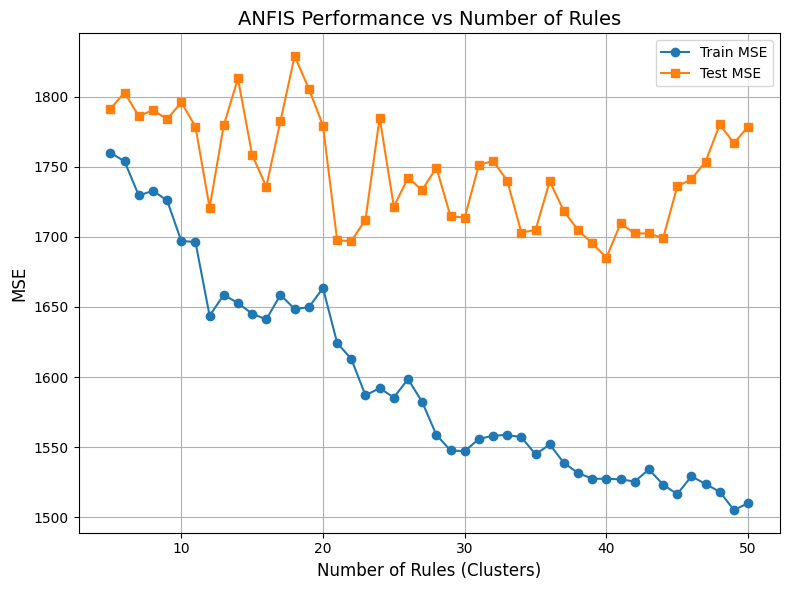

In [18]:
import numpy as np  
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  
from sklearn.cluster import KMeans  
import matplotlib.pyplot as plt  

class ANFIS:
    def __init__(self, n_clusters, X): # X input data shape (N, F)
        self.n_clusters, self.n_features = n_clusters, X.shape[1]  # set sizes
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)  # init clusters
        self.centers = kmeans.cluster_centers_  # center shape (K, F)
        labels      = kmeans.labels_               # (N,)
        diffs = X[:, None, :] - self.centers[None, :, :] # N, K, F)
        one_hot = np.eye(self.n_clusters, dtype=bool)[labels]  # (N, K)
        mask = (~one_hot[:, :, None]).repeat(self.n_features, axis=2) # (N,K,F)
        raw_stds = np.ma.array(diffs, mask=mask).std(axis=0).filled(0)
        self.stds = np.maximum(raw_stds, 1)

    def _membership(self, X):
        diffs = X[:, None, :] - self.centers[None, :, :]  # broadcast diff
        sq = diffs**2 / (2 * self.stds[None, :, :]**2)  # Distance
        M = np.exp(-sq.sum(axis=2))  # sum over features resize-> (N,K)
        return M / M.sum(axis=1, keepdims=True)  # normalize memberships

    def fit(self, X, y, Xv, yv, epochs=100, lr=1e-4, patience=20):
        N = X.shape[0]
        best_mse, wait = np.inf, 0  # early-stopping trackers
        for ep in range(epochs):
            M = self._membership(X)  # (N,K)
            theta = np.linalg.lstsq(M, y, rcond=None)[0]  # solve Θ = argmin||MΘ−y||
            self.w = theta  # consequent weights only
            y_pred = M @ self.w  # model output
            mse = mean_squared_error(y, y_pred)  # train MSE

            Mv = self._membership(Xv)  # val memberships
            val_mse = mean_squared_error(yv, Mv @ self.w)  # val MSE

            # early stopping check
            if val_mse < best_mse:
                best_mse, wait = val_mse, 0
            else:
                wait += 1
            if wait >= patience:
                break
        
        return mse  # return final training MSE

    def predict(self, X):
        M = self._membership(X)  # get fuzzy memberships
        return M @ self.w  # weighted sum without bias

    def test(self, X, y):
        y_pred = self.predict(X)  # predict test set
        mse = mean_squared_error(y, y_pred)
        return mse  # only return test MSE


if __name__ == '__main__':
    df = df_final  # load data

    # Use all columns except the last as features, last column as target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler().fit(Xt)
    Xt, Xs = sc.transform(Xt), sc.transform(Xs)  # scale features
    Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15, random_state=42)

    train_mse_list = []
    test_mse_list = []
    rule_counts = range(5, 51)  # from 5 to 50 rules

    for n_rules in rule_counts:
        print(f"\nTraining ANFIS with {n_rules} rules...")
        model = ANFIS(n_clusters=n_rules, X=Xtr)
        train_mse = model.fit(Xtr, ytr, Xv, yv, epochs=250, lr=0.01, patience=15)
        test_mse = model.test(Xs, ys)

        train_mse_list.append(train_mse)
        test_mse_list.append(test_mse)

    # Plot results
    plt.figure(figsize=(8,6))
    plt.plot(rule_counts, train_mse_list, marker='o', label='Train MSE')
    plt.plot(rule_counts, test_mse_list, marker='s', label='Test MSE')
    plt.xlabel("Number of Rules (Clusters)", fontsize=12)
    plt.ylabel("MSE", fontsize=12)
    plt.title("ANFIS Performance vs Number of Rules", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## ANFIS 1ST ORDER

In [155]:
import numpy as np  
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  
from sklearn.cluster import KMeans  
import matplotlib.pyplot as plt  

class ANFIS:
    def __init__(self, n_clusters, X): # X input data shape (N, F)
        self.n_clusters, self.n_features = n_clusters, X.shape[1]  # set sizes
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)  # init clusters
        self.centers = kmeans.cluster_centers_  # center shape (K, F)
        labels      = kmeans.labels_               # (N,)
        diffs = X[:, None, :] - self.centers[None, :, :] # N, K, F)
        one_hot = np.eye(self.n_clusters, dtype=bool)[labels]  # (N, K)
        mask = (~one_hot[:, :, None]).repeat(self.n_features, axis=2) # (N,K,F)
        raw_stds = np.ma.array(diffs, mask=mask).std(axis=0).filled(0)
        self.stds = np.maximum(raw_stds, 1)


    def _membership(self, X):
        diffs = X[:, None, :] - self.centers[None, :, :]  # broadcast diff
        sq = diffs**2 / (2 * self.stds[None, :, :]**2)  # Distance
        M = np.exp(-sq.sum(axis=2))  # sum over features resize-> (N,K)
        return M / M.sum(axis=1, keepdims=True)  # normalize memberships

    def fit(self, X, y, Xv, yv, epochs=100, lr=1e-4, patience=20):
        N = X.shape[0]
        best_mse, wait = np.inf, 0  # early-stopping trackers
        
        for ep in range(epochs):
            M = self._membership(X)  # (N,K)
            
            # First-order consequent: each rule has linear function f_i = w_i0 + w_i1*x1 + ... + w_iF*xF
            # Build design matrix: for each sample, concatenate [M_i * 1, M_i * x1, M_i * x2, ..., M_i * xF] for all rules
            # Shape: (N, K*(F+1)) where each rule contributes (F+1) features
            X_augmented = []
            for k in range(self.n_clusters):
                # For rule k: multiply membership by [1, x1, x2, ..., xF]
                M_k = M[:, k:k+1]  # (N, 1)
                X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
                X_augmented.append(M_k * X_with_bias)  # (N, F+1)
            
            design_matrix = np.concatenate(X_augmented, axis=1)  # (N, K*(F+1))
            
            # Solve for all consequent parameters: theta shape (K*(F+1),)

                
            lambda_reg = 1e-2 #ridge regularization
            theta = np.linalg.lstsq(design_matrix.T @ design_matrix + lambda_reg*np.eye(design_matrix.shape[1]),
             design_matrix.T @ y, rcond=None)[0]
            
            




            self.w = theta.reshape(self.n_clusters, self.n_features + 1)  # (K, F+1)
            
            # Compute output: sum over rules of (membership * linear_function)
            X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
            rule_outputs = (X_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (N, K)
            y_pred = (M * rule_outputs).sum(axis=1)  # (N,)
            
            mse = mean_squared_error(y, y_pred)  # train MSE

            # Validation
            Mv = self._membership(Xv)  # val memberships
            Nv = Xv.shape[0]
            Xv_with_bias = np.concatenate([np.ones((Nv, 1)), Xv], axis=1)  # (Nv, F+1)
            rule_outputs_v = (Xv_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (Nv, K)
            yv_pred = (Mv * rule_outputs_v).sum(axis=1)  # (Nv,)
            val_mse = mean_squared_error(yv, yv_pred)
            
            print(f"Epoch {ep+1}, Train MSE: {mse:.4f}, Val MSE: {val_mse:.4f}", flush=True)

            # Gradient computation for antecedent parameters
            err = (y - y_pred)[:, None]  # (N, 1) error
            diffs = X[:, None, :] - self.centers[None, :, :]  # (N, K, F)
            
            # Compute gradients for centers and stds
            # For first-order: ∂y/∂μ and ∂y/∂σ are more complex due to linear consequents
            dM_dc = M[:,:,None] * diffs / (self.stds[None,:,:]**2)  # (N, K, F)
            dM_ds = M[:,:,None] * diffs**2 / (self.stds[None,:,:]**3)  # (N, K, F)
            
            # Output contribution from each rule
            X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
            rule_outputs = (X_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (N, K)
            
            # ∂y/∂M_k = f_k (output of rule k)
            dY_dM = rule_outputs  # (N, K)
            
            # Chain rule: ∂y/∂c = ∂y/∂M * ∂M/∂c
            dY_dc = dY_dM[:, :, None] * dM_dc  # (N, K, F)
            dY_ds = dY_dM[:, :, None] * dM_ds  # (N, K, F)
            
            grad_c = -2/N * (err[:, :, None] * dY_dc).sum(axis=0)  # (K, F)
            grad_s = -2/N * (err[:, :, None] * dY_ds).sum(axis=0)  # (K, F)
            
            grad_c = np.clip(grad_c, -1, 1)  # stability clip
            grad_s = np.clip(grad_s, -0.5, 0.5)

            self.centers -= lr * grad_c  # update means
            self.stds = np.maximum(self.stds - lr * grad_s, 0.1)  # update stds

            if val_mse < best_mse:
                best_mse, wait = val_mse, 0
            else:
                wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {ep+1}, best Val MSE: {best_mse:.4f}", flush=True)
                break

    def predict(self, X):
        M = self._membership(X)  # (N, K)
        N = X.shape[0]
        X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
        rule_outputs = (X_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (N, K)
        return (M * rule_outputs).sum(axis=1)  # (N,)

    def test(self, X, y):
        y_pred = self.predict(X)  # predict test set
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mape = np.mean(np.abs((y - y_pred) / y)) * 100

        print(f"Test MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}, MAPE: {mape:.2f}%", flush=True)

        return mse, rmse, mae, r2 



if __name__ == '__main__':
    df = df_final  # load data

    # Use all columns except the last as features, last column as target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.2, random_state=39)
    sc = StandardScaler().fit(Xt)
    Xt, Xs = sc.transform(Xt), sc.transform(Xs)  # scale features
    Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15, random_state=39)

    model = ANFIS(n_clusters=7, X=Xtr)  # init ANFIS
    model.fit(Xtr, ytr, Xv, yv, epochs=250, lr=0.01, patience=15)  # train
    model.test(Xs, ys)  # evaluate

Epoch 1, Train MSE: 1355.6918, Val MSE: 1451.4476
Epoch 2, Train MSE: 1355.2452, Val MSE: 1454.6979
Epoch 3, Train MSE: 1354.6772, Val MSE: 1458.7383
Epoch 4, Train MSE: 1354.1387, Val MSE: 1463.3973
Epoch 5, Train MSE: 1353.5791, Val MSE: 1468.6448
Epoch 6, Train MSE: 1353.1113, Val MSE: 1474.4614
Epoch 7, Train MSE: 1352.5652, Val MSE: 1480.8365
Epoch 8, Train MSE: 1352.1150, Val MSE: 1487.5888
Epoch 9, Train MSE: 1351.8920, Val MSE: 1494.0725
Epoch 10, Train MSE: 1351.8228, Val MSE: 1499.4699
Epoch 11, Train MSE: 1351.8557, Val MSE: 1502.8886
Epoch 12, Train MSE: 1352.0996, Val MSE: 1508.1058
Epoch 13, Train MSE: 1352.3183, Val MSE: 1511.2884
Epoch 14, Train MSE: 1352.5522, Val MSE: 1514.2061
Epoch 15, Train MSE: 1352.7558, Val MSE: 1517.3470
Epoch 16, Train MSE: 1352.9154, Val MSE: 1519.0131
Early stopping at epoch 16, best Val MSE: 1451.4476
Test MSE: 1773.4195, RMSE: 42.1120, MAE: 32.1426, R2: 0.1300, MAPE: 12.36%


**Looping ANFIS from 5 to 50 rules with 10 models per run at different random seeds**

In [60]:
import numpy as np  
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  
from sklearn.cluster import KMeans  
import matplotlib.pyplot as plt  

class ANFIS:
    def __init__(self, n_clusters, X): # X input data shape (N, F)
        self.n_clusters, self.n_features = n_clusters, X.shape[1]  # set sizes
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)  # init clusters
        self.centers = kmeans.cluster_centers_  # center shape (K, F)
        labels      = kmeans.labels_               # (N,)
        diffs = X[:, None, :] - self.centers[None, :, :] # N, K, F)
        one_hot = np.eye(self.n_clusters, dtype=bool)[labels]  # (N, K)
        mask = (~one_hot[:, :, None]).repeat(self.n_features, axis=2) # (N,K,F)
        raw_stds = np.ma.array(diffs, mask=mask).std(axis=0).filled(0)
        self.stds = np.maximum(raw_stds, 1)


    def _membership(self, X):
        diffs = X[:, None, :] - self.centers[None, :, :]  # broadcast diff
        sq = diffs**2 / (2 * self.stds[None, :, :]**2)  # Distance
        M = np.exp(-sq.sum(axis=2))  # sum over features resize-> (N,K)
        return M / M.sum(axis=1, keepdims=True)  # normalize memberships

    def fit(self, X, y, Xv, yv, epochs=100, lr=1e-4, patience=20, verbose=True):
        N = X.shape[0]
        best_mse, wait = np.inf, 0  # early-stopping trackers
        
        for ep in range(epochs):
            M = self._membership(X)  # (N,K)
            
            # First-order consequent: each rule has linear function f_i = w_i0 + w_i1*x1 + ... + w_iF*xF
            # Build design matrix: for each sample, concatenate [M_i * 1, M_i * x1, M_i * x2, ..., M_i * xF] for all rules
            # Shape: (N, K*(F+1)) where each rule contributes (F+1) features
            X_augmented = []
            for k in range(self.n_clusters):
                # For rule k: multiply membership by [1, x1, x2, ..., xF]
                M_k = M[:, k:k+1]  # (N, 1)
                X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
                X_augmented.append(M_k * X_with_bias)  # (N, F+1)
            
            design_matrix = np.concatenate(X_augmented, axis=1)  # (N, K*(F+1))
            
            
            # Solve for all consequent parameters: theta shape (K*(F+1),)


            lambda_reg = 1e-1 #ridge regularization
            theta = np.linalg.lstsq(design_matrix.T @ design_matrix + lambda_reg*np.eye(design_matrix.shape[1]),
             design_matrix.T @ y, rcond=None)[0]




            self.w = theta.reshape(self.n_clusters, self.n_features + 1)  # (K, F+1)
            
            # Compute output: sum over rules of (membership * linear_function)
            X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
            rule_outputs = (X_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (N, K)
            y_pred = (M * rule_outputs).sum(axis=1)  # (N,)
            
            mse = mean_squared_error(y, y_pred)  # train MSE

            # Validation
            Mv = self._membership(Xv)  # val memberships
            Nv = Xv.shape[0]
            Xv_with_bias = np.concatenate([np.ones((Nv, 1)), Xv], axis=1)  # (Nv, F+1)
            rule_outputs_v = (Xv_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (Nv, K)
            yv_pred = (Mv * rule_outputs_v).sum(axis=1)  # (Nv,)
            val_mse = mean_squared_error(yv, yv_pred)
            
            if verbose:
                print(f"Epoch {ep+1}, Train MSE: {mse:.4f}, Val MSE: {val_mse:.4f}", flush=True)

            # Gradient computation for antecedent parameters
            err = (y - y_pred)[:, None]  # (N, 1) error
            diffs = X[:, None, :] - self.centers[None, :, :]  # (N, K, F)
            
            # Compute gradients for centers and stds
            # For first-order: ∂y/∂μ and ∂y/∂σ are more complex due to linear consequents
            dM_dc = M[:,:,None] * diffs / (self.stds[None,:,:]**2)  # (N, K, F)
            dM_ds = M[:,:,None] * diffs**2 / (self.stds[None,:,:]**3)  # (N, K, F)
            
            # Output contribution from each rule
            X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
            rule_outputs = (X_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (N, K)
            
            # ∂y/∂M_k = f_k (output of rule k)
            dY_dM = rule_outputs  # (N, K)
            
            # Chain rule: ∂y/∂c = ∂y/∂M * ∂M/∂c
            dY_dc = dY_dM[:, :, None] * dM_dc  # (N, K, F)
            dY_ds = dY_dM[:, :, None] * dM_ds  # (N, K, F)
            
            grad_c = -2/N * (err[:, :, None] * dY_dc).sum(axis=0)  # (K, F)
            grad_s = -2/N * (err[:, :, None] * dY_ds).sum(axis=0)  # (K, F)
            
            grad_c = np.clip(grad_c, -1, 1)  # stability clip
            grad_s = np.clip(grad_s, -0.5, 0.5)

            self.centers -= lr * grad_c  # update means
            self.stds = np.maximum(self.stds - lr * grad_s, 0.1)  # update stds

            if val_mse < best_mse:
                best_mse, wait = val_mse, 0
            else:
                wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {ep+1}, best Val MSE: {best_mse:.4f}", flush=True)
                break

    def predict(self, X):
        M = self._membership(X)  # (N, K)
        N = X.shape[0]
        X_with_bias = np.concatenate([np.ones((N, 1)), X], axis=1)  # (N, F+1)
        rule_outputs = (X_with_bias[:, None, :] * self.w[None, :, :]).sum(axis=2)  # (N, K)
        return (M * rule_outputs).sum(axis=1)  # (N,)

    def test(self, X, y):
        y_pred = self.predict(X)  # predict test set
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mape = np.mean(np.abs((y - y_pred) / y)) * 100

        print(f"Test MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}, MAPE: {mape:.2f}%", flush=True)

        return mse, rmse, mae, r2 



if __name__ == '__main__':
    import pickle
    import os
    
    df = df_final  # load data

    # Use all columns except the last as features, last column as target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Configuration
    n_rules_range = range(1, 51, 1)  # 5 to 50 with increment of 1
    random_seeds = [42, 123, 456, 789, 1011]  # 5 different random seeds
    n_runs = 10  # train each model 10 times (2 runs per seed)
    results_file = 'anfis_results.pkl'
    
    # Check if results already exist
    if os.path.exists(results_file):
        print(f"Loading existing results from {results_file}")
        with open(results_file, 'rb') as f:
            results = pickle.load(f)
        print(f"Loaded results for {len(results['n_rules'])} configurations")
    else:
        print("No existing results found. Starting training...")
        
        results = {
            'n_rules': [],
            'train_mse_mean': [],
            'train_mse_min': [],
            'train_mse_max': [],
            'train_mse_std': [],
            'test_mse_mean': [],
            'test_mse_min': [],
            'test_mse_max': [],
            'test_mse_std': [],
            'all_train_mses': [],  # Store all individual runs
            'all_test_mses': []
        }
        
        for n_rules in n_rules_range:
            print(f"\n{'='*60}")
            print(f"Training with {n_rules} rules")
            print(f"{'='*60}")
            
            train_mses = []
            test_mses = []
            
            # Train 10 times with different seeds
            for run_idx in range(n_runs):
                seed = random_seeds[run_idx % len(random_seeds)] + (run_idx // len(random_seeds))
                
                print(f"Run {run_idx + 1}/{n_runs} (seed={seed})...", end=' ', flush=True)
                
                # Split data with current seed
                Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.2, random_state=seed)
                sc = StandardScaler().fit(Xt)
                Xt, Xs = sc.transform(Xt), sc.transform(Xs)
                Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15, random_state=seed)
                
                # Train model (verbose=False to suppress epoch outputs)
                model = ANFIS(n_clusters=n_rules, X=Xtr)
                model.fit(Xtr, ytr, Xv, yv, epochs=250, lr=0.01, patience=15, verbose=False)
                
                # Get final train MSE
                train_pred = model.predict(Xtr)
                train_mse = mean_squared_error(ytr, train_pred)
                train_mses.append(train_mse)
                
                # Get test MSE
                test_pred = model.predict(Xs)
                test_mse = mean_squared_error(ys, test_pred)
                test_mses.append(test_mse)
                
                print(f"Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
            
            # Store statistics
            results['n_rules'].append(n_rules)
            results['train_mse_mean'].append(np.mean(train_mses))
            results['train_mse_min'].append(np.min(train_mses))
            results['train_mse_max'].append(np.max(train_mses))
            results['train_mse_std'].append(np.std(train_mses))
            results['test_mse_mean'].append(np.mean(test_mses))
            results['test_mse_min'].append(np.min(test_mses))
            results['test_mse_max'].append(np.max(test_mses))
            results['test_mse_std'].append(np.std(test_mses))
            results['all_train_mses'].append(train_mses)
            results['all_test_mses'].append(test_mses)
            
            print(f"\nSummary for {n_rules} rules:")
            print(f"  Train MSE: {np.mean(train_mses):.4f} ± {np.std(train_mses):.4f} [{np.min(train_mses):.4f}, {np.max(train_mses):.4f}]")
            print(f"  Test MSE:  {np.mean(test_mses):.4f} ± {np.std(test_mses):.4f} [{np.min(test_mses):.4f}, {np.max(test_mses):.4f}]")
        
        # Save results
        with open(results_file, 'wb') as f:
            pickle.dump(results, f)
        print(f"\nResults saved to {results_file}")
    
    

No existing results found. Starting training...

Training with 1 rules
Run 1/10 (seed=42)... Train MSE: 1615.1923, Test MSE: 1651.4511
Run 2/10 (seed=123)... Train MSE: 1596.7982, Test MSE: 1759.1105
Run 3/10 (seed=456)... Train MSE: 1615.8413, Test MSE: 1539.4499
Run 4/10 (seed=789)... Train MSE: 1597.0550, Test MSE: 1580.9294
Run 5/10 (seed=1011)... Train MSE: 1627.4645, Test MSE: 1648.0319
Run 6/10 (seed=43)... Train MSE: 1648.2589, Test MSE: 1479.4073
Run 7/10 (seed=124)... Train MSE: 1630.2034, Test MSE: 1600.8952
Run 8/10 (seed=457)... Train MSE: 1600.7535, Test MSE: 1677.2047
Run 9/10 (seed=790)... Train MSE: 1625.6755, Test MSE: 1617.8427
Run 10/10 (seed=1012)... Train MSE: 1626.6780, Test MSE: 1672.2113

Summary for 1 rules:
  Train MSE: 1618.3921 ± 15.7638 [1596.7982, 1648.2589]
  Test MSE:  1622.6534 ± 74.3004 [1479.4073, 1759.1105]

Training with 2 rules
Run 1/10 (seed=42)... Train MSE: 1478.6388, Test MSE: 1593.7074
Run 2/10 (seed=123)... Train MSE: 1496.7847, Test MSE: 17


Creating plots...
Plot saved as 'anfis_rules_vs_mse.png'


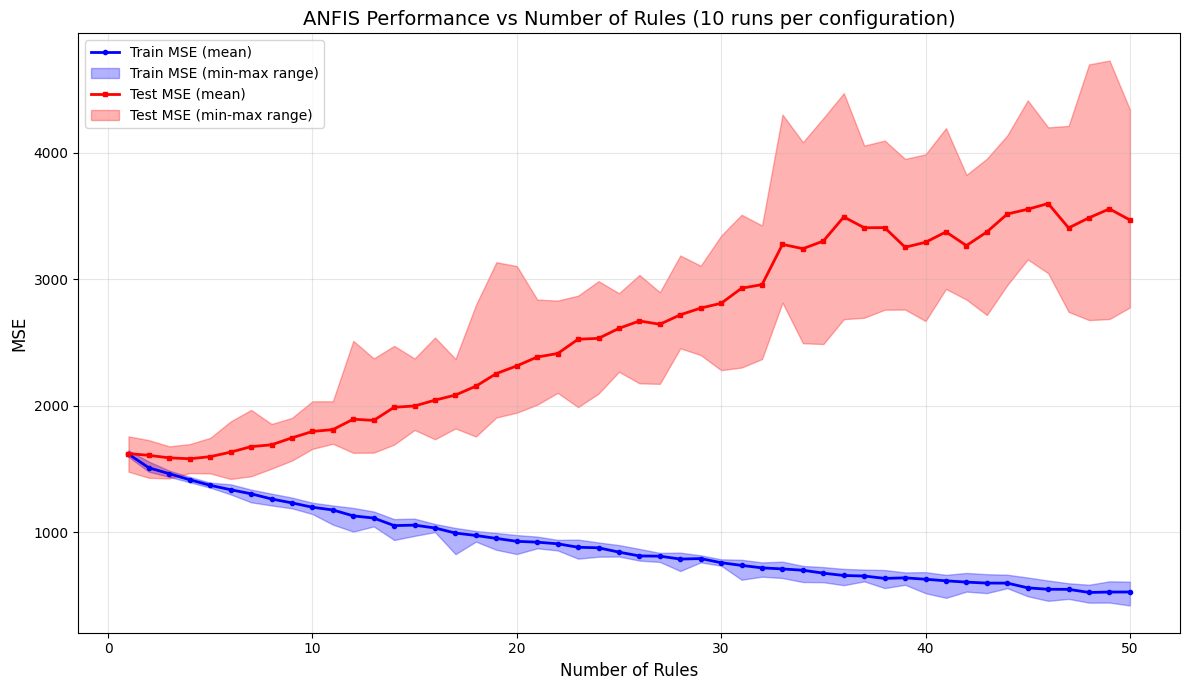


Best configuration: 4 rules with average test MSE: 1581.6596
At best config - Train MSE: 1415.4840


In [61]:
# ==================== PLOTTING SECTION ====================
print("\n" + "="*60)
print("Creating plots...")
print("="*60)

n_rules_list = results['n_rules']

# Create plot
plt.figure(figsize=(12, 7))

# Plot train MSE
plt.plot(n_rules_list, results['train_mse_mean'], 'b-', linewidth=2, label='Train MSE (mean)', marker='o', markersize=3)
plt.fill_between(n_rules_list, results['train_mse_min'], results['train_mse_max'], 
                 alpha=0.3, color='blue', label='Train MSE (min-max range)')

# Plot test MSE
plt.plot(n_rules_list, results['test_mse_mean'], 'r-', linewidth=2, label='Test MSE (mean)', marker='s', markersize=3)
plt.fill_between(n_rules_list, results['test_mse_min'], results['test_mse_max'], 
                 alpha=0.3, color='red', label='Test MSE (min-max range)')

plt.xlabel('Number of Rules', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('ANFIS Performance vs Number of Rules (10 runs per configuration)', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anfis_rules_vs_mse.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'anfis_rules_vs_mse.png'")
plt.show()

# Print best configuration
best_test_idx = np.argmin(results['test_mse_mean'])
best_n_rules = results['n_rules'][best_test_idx]
best_test_mse = results['test_mse_mean'][best_test_idx]
print(f"\nBest configuration: {best_n_rules} rules with average test MSE: {best_test_mse:.4f}")
print(f"At best config - Train MSE: {results['train_mse_mean'][best_test_idx]:.4f}")

## UQ Bombshell

**random grid partitioning for explainability**


**it is important to mention that we did grid search to see best parameters, then we did parameter sweep to explore minimal number of rules, and that we also investigate training with fixed and learned q values but then landed to the conclusion that q value should remain fixed**

**parameter sweep without random seed**

Data sizes -> train: 884, val: 221, test: 277

=== Sweeping n_rules = 1 ===
Initializing with grid partitioning... (n_rules=1)
Using random grid sampling (uniform grid would create 8192 rules)
Initialized 1 rules with random grid sampling
Average FOU width: 1.3902

Training Configuration:
  Batch size: 32
  Batches per epoch: 27
  L1 regularization: 0.0
  L2 regularization: 0.005
  Antecedents: Trainable
  Early stopping patience: 40

Epoch   1 | Train MSE: 45756.403276 | Val MSE: 45794.298791 | η_cons: 0.010000 | η_ant: 0.001000
Epoch   2 | Train MSE: 26596.220945 | Val MSE: 26625.585979 | η_cons: 0.010500 | η_ant: 0.001050
Epoch   3 | Train MSE: 15370.946457 | Val MSE: 15365.915777 | η_cons: 0.011025 | η_ant: 0.001103
Epoch   4 | Train MSE: 8997.749212 | Val MSE: 8948.276966 | η_cons: 0.011576 | η_ant: 0.001158
Epoch   5 | Train MSE: 5464.016474 | Val MSE: 5420.808233 | η_cons: 0.012155 | η_ant: 0.001216
Epoch   6 | Train MSE: 3553.529027 | Val MSE: 3506.720674 | η_cons: 0.012763 | η

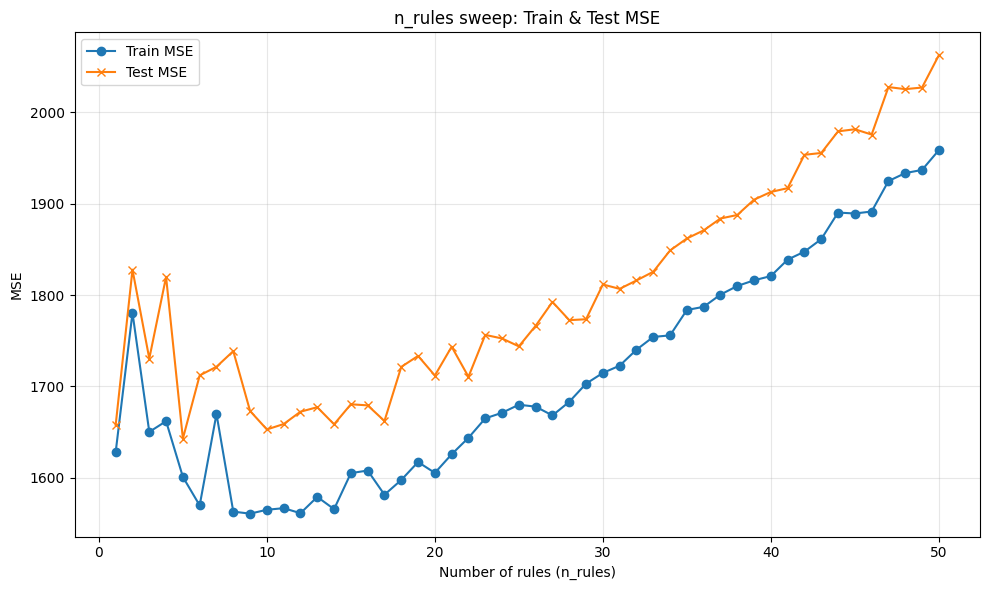


Top 5 configs by test MSE:
 n_rules   train_mse     val_mse    test_mse  test_mae  test_r2  test_mape  train_time_s
       5 1600.811759 1672.318405 1642.748741 31.034542 0.137566  11.926788      4.051308
      10 1564.850061 1674.844026 1652.785601 31.702023 0.132297  12.162830      5.618393
       1 1628.073342 1541.124149 1657.770678 31.019884 0.129680  12.049006      0.391729
      14 1565.516464 1632.819340 1658.423728 31.703154 0.129337  12.079225     12.558015
      11 1566.589585 1677.199433 1658.693709 31.834807 0.129195  12.196242     10.185672


In [78]:
# propoer parameter sweep
# parameter sweep over n_rules (5 to 50)
# testing 5 to 50


# parameter sweep over n_rules

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import torch
import time
import csv

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ---------------- IT2_TSK_ANFIS class (unchanged functionality) ----------------
class IT2_TSK_ANFIS:
    """
    Interval Type-2 TSK ANFIS with PyTorch autodiff antecedent updates.
    Kept functionally the same as your provided implementation.
    """
    def __init__(self, n_rules, X, m1=1.5, m2=3.0, min_sigma=0.05):
        self.n_rules = n_rules
        self.n_features = X.shape[1]
        self.min_sigma = min_sigma
        self.m1 = m1
        self.m2 = m2

        # Initialize using grid partitioning
        print(f"Initializing with grid partitioning... (n_rules={n_rules})")
        self._init_with_grid(X)

        # TSK consequent parameters
        self.w = np.random.randn(self.n_rules, self.n_features) * 0.01  # Smaller initialization
        self.b = np.random.randn(self.n_rules) * 0.01

        # Design factor q
        self.q = 0.5

        # Separate adaptive learning rates
        self.eta_consequent = 0.01
        self.eta_antecedent = 0.001  # Much smaller for antecedents
        self.prev_error = np.inf
        
        # Best model storage
        self.best_w = None
        self.best_b = None
        self.best_c1 = None
        self.best_c2 = None

    # ---------------- Grid-Based Initialization ----------------
    def _init_with_grid(self, X):
        N = X.shape[0]
        rules_per_dim = max(2, int(np.ceil(self.n_rules ** (1.0 / self.n_features))))
        potential_rules = rules_per_dim ** self.n_features
        
        if potential_rules > 2 * self.n_rules or self.n_features > 8:
            # Use random/hybrid approach for high dimensions
            print(f"Using random grid sampling (uniform grid would create {potential_rules} rules)")
            self._init_with_random_grid(X)
            return
        
        if potential_rules != self.n_rules:
            print(f"Adjusting rules from {self.n_rules} to {potential_rules} for uniform grid")
            self.n_rules = potential_rules
        
        feature_mins = X.min(axis=0)
        feature_maxs = X.max(axis=0)
        feature_ranges = feature_maxs - feature_mins
        
        self.c1 = np.zeros((self.n_rules, self.n_features))
        self.c2 = np.zeros((self.n_rules, self.n_features))
        self.centers = np.zeros((self.n_rules, self.n_features))
        
        grid_indices = np.array(np.meshgrid(*[np.arange(rules_per_dim) for _ in range(self.n_features)])).T.reshape(-1, self.n_features)
        partition_widths = feature_ranges / rules_per_dim
        uncertainty_factor = 0.2  # 20% of partition width
        
        for rule_idx in range(self.n_rules):
            for feat_idx in range(self.n_features):
                grid_pos = grid_indices[rule_idx, feat_idx]
                partition_center = feature_mins[feat_idx] + (grid_pos + 0.5) * partition_widths[feat_idx]
                uncertainty_width = partition_widths[feat_idx] * uncertainty_factor
                
                self.c1[rule_idx, feat_idx] = partition_center - uncertainty_width / 2
                self.c2[rule_idx, feat_idx] = partition_center + uncertainty_width / 2
                self.centers[rule_idx, feat_idx] = partition_center
        
        self.stds = np.zeros((self.n_rules, self.n_features))
        for feat_idx in range(self.n_features):
            std_value = partition_widths[feat_idx] * 0.5
            self.stds[:, feat_idx] = max(std_value, self.min_sigma)
        
        print(f"Initialized {self.n_rules} rules with grid partitioning ({rules_per_dim} per dimension)")
        print(f"Average FOU width: {np.mean(self.c2 - self.c1):.4f}")

    def _init_with_random_grid(self, X):
        N = X.shape[0]
        feature_mins = X.min(axis=0)
        feature_maxs = X.max(axis=0)
        feature_ranges = feature_maxs - feature_mins
        
        self.c1 = np.zeros((self.n_rules, self.n_features))
        self.c2 = np.zeros((self.n_rules, self.n_features))
        self.centers = np.zeros((self.n_rules, self.n_features))
        self.stds = np.zeros((self.n_rules, self.n_features))
        
        typical_partitions = int(np.ceil(self.n_rules ** (1.0 / self.n_features)))
        partition_widths = feature_ranges / max(1, typical_partitions)
        uncertainty_factor = 0.2
        
        for rule_idx in range(self.n_rules):
            for feat_idx in range(self.n_features):
                segment_size = feature_ranges[feat_idx] / max(1, self.n_rules)
                segment_start = feature_mins[feat_idx] + rule_idx * segment_size
                segment_center = segment_start + np.random.uniform(0, max(1e-6, segment_size))
                uncertainty_width = partition_widths[feat_idx] * uncertainty_factor
                
                self.c1[rule_idx, feat_idx] = segment_center - uncertainty_width / 2
                self.c2[rule_idx, feat_idx] = segment_center + uncertainty_width / 2
                self.centers[rule_idx, feat_idx] = segment_center
                self.stds[rule_idx, feat_idx] = max(partition_widths[feat_idx] * 0.5, self.min_sigma)
        
        print(f"Initialized {self.n_rules} rules with random grid sampling")
        print(f"Average FOU width: {np.mean(self.c2 - self.c1):.4f}")

    # ---------------- Memberships and Firing Strengths ----------------
    def _compute_memberships(self, X):
        N = X.shape[0]
        mu_lower = np.zeros((N, self.n_rules))
        mu_upper = np.zeros((N, self.n_rules))

        for k in range(self.n_rules):
            mu_lower_feat = np.ones(N)
            mu_upper_feat = np.ones(N)
            for f in range(self.n_features):
                x_f = X[:, f]
                c1_kf = self.c1[k, f]
                c2_kf = self.c2[k, f]
                c_mid = (c1_kf + c2_kf) / 2
                sigma_kf = self.stds[k, f]

                mu_l = np.where(x_f <= c_mid,
                                np.exp(-0.5 * ((x_f - c2_kf) / sigma_kf) ** 2),
                                np.exp(-0.5 * ((x_f - c1_kf) / sigma_kf) ** 2))

                mu_u = np.where(x_f < c1_kf,
                                np.exp(-0.5 * ((x_f - c1_kf) / sigma_kf) ** 2),
                                np.where(x_f <= c2_kf,
                                         1.0,
                                         np.exp(-0.5 * ((x_f - c2_kf) / sigma_kf) ** 2)))

                mu_lower_feat *= mu_l
                mu_upper_feat *= mu_u

            mu_lower[:, k] = mu_lower_feat
            mu_upper[:, k] = mu_upper_feat

        return mu_lower, mu_upper

    def _compute_firing_strengths(self, X):
        f_lower, f_upper = self._compute_memberships(X)
        f_lower = np.maximum(f_lower, 1e-12)
        f_upper = np.maximum(f_upper, 1e-12)
        return f_lower, f_upper

    # ---------------- Output Computation ----------------
    def _compute_output(self, X, f_lower, f_upper):
        N = X.shape[0]
        y_consequents = X @ self.w.T + self.b
        sum_f_lower = f_lower.sum(axis=1, keepdims=True)
        sum_f_upper = f_upper.sum(axis=1, keepdims=True)
        f_lower_norm = f_lower / np.maximum(sum_f_lower, 1e-12)
        f_upper_norm = f_upper / np.maximum(sum_f_upper, 1e-12)
        u_lower = (f_lower_norm * y_consequents).sum(axis=1)
        u_upper = (f_upper_norm * y_consequents).sum(axis=1)
        u = self.q * u_lower + (1 - self.q) * u_upper
        return u, u_lower, u_upper, f_lower_norm, f_upper_norm, y_consequents

    # ---------------- Prediction Methods ----------------
    def predict(self, X):
        f_lower, f_upper = self._compute_firing_strengths(X)
        u, _, _, _, _, _ = self._compute_output(X, f_lower, f_upper)
        return u

    def predict_interval(self, X):
        f_lower, f_upper = self._compute_firing_strengths(X)
        _, u_lower, u_upper, _, _, _ = self._compute_output(X, f_lower, f_upper)
        return np.minimum(u_lower, u_upper), np.maximum(u_lower, u_upper)

    # ---------------- Training with Improvements ----------------
    def fit(self, X, y, X_val, y_val, epochs=100, patience=30, batch_size=64, 
            freeze_antecedents=True, lambda_l1=0.005, lambda_l2=0.01):
        """
        Train the IT2-TSK-ANFIS model with mini-batch gradient descent.
        """
        N = X.shape[0]
        n_batches = max(1, N // batch_size)
        best_val_mse = np.inf
        wait = 0
        min_delta = 0.01  # Minimum improvement threshold
        
        print(f"\nTraining Configuration:")
        print(f"  Batch size: {batch_size}")
        print(f"  Batches per epoch: {n_batches}")
        print(f"  L1 regularization: {lambda_l1}")
        print(f"  L2 regularization: {lambda_l2}")
        print(f"  Antecedents: {'Frozen' if freeze_antecedents else 'Trainable'}")
        print(f"  Early stopping patience: {patience}")
        print()

        for epoch in range(epochs):
            # Shuffle data for each epoch
            indices = np.random.permutation(N)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_train_loss = 0
            
            # Mini-batch training
            for batch in range(n_batches):
                start_idx = batch * batch_size
                end_idx = min(start_idx + batch_size, N)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                
                # Forward pass
                f_lower, f_upper = self._compute_firing_strengths(X_batch)
                u, u_lower, u_upper, f_l_norm, f_u_norm, y_cons = self._compute_output(X_batch, f_lower, f_upper)
                error = u - y_batch
                batch_mse = np.mean(error ** 2)
                epoch_train_loss += batch_mse
                
                # Update consequent parameters with L1 + L2 regularization
                for j in range(self.n_rules):
                    factor = (self.q * f_l_norm[:, j] / (f_l_norm.sum(axis=1) + 1e-12) +
                             (1 - self.q) * f_u_norm[:, j] / (f_u_norm.sum(axis=1) + 1e-12))
                    
                    grad_w = (error[:, None] * factor[:, None] * X_batch).mean(axis=0)
                    grad_b = (error * factor).mean()
                    
                    # Apply L1 and L2 regularization
                    grad_w += lambda_l2 * self.w[j] + lambda_l1 * np.sign(self.w[j])
                    grad_b += lambda_l2 * self.b[j] + lambda_l1 * np.sign(self.b[j])
                    
                    # Gradient descent update
                    self.w[j] -= self.eta_consequent * grad_w
                    self.b[j] -= self.eta_consequent * grad_b
            
            # Calculate epoch metrics
            train_mse = epoch_train_loss / n_batches
            val_pred = self.predict(X_val)
            val_mse = mean_squared_error(y_val, val_pred)
            
            # Compute full training set prediction for monitoring
            train_pred = self.predict(X)
            train_mse_full = mean_squared_error(y, train_pred)
            
            if epoch % 5 == 0 or epoch < 10:
                print(f"Epoch {epoch+1:3d} | Train MSE: {train_mse_full:.6f} | Val MSE: {val_mse:.6f} | "
                      f"η_cons: {self.eta_consequent:.6f} | η_ant: {self.eta_antecedent:.6f}")
            
            # Fix q to 0.5 (as in original)
            self.q = 0.5
            
            # ----------------- Antecedent update: PyTorch autodiff -----------------
            if not freeze_antecedents and epoch % 10 == 0 and epoch > 0:
                X_t = torch.tensor(X, dtype=torch.float32)              # shape (N, F)
                y_t = torch.tensor(y, dtype=torch.float32)              # shape (N,)
                w_t = torch.tensor(self.w.astype(np.float32), requires_grad=False)  # shape (R, F)
                b_t = torch.tensor(self.b.astype(np.float32), requires_grad=False)  # shape (R,)
                c1_t = torch.tensor(self.c1.astype(np.float32), requires_grad=True) # shape (R, F)
                c2_t = torch.tensor(self.c2.astype(np.float32), requires_grad=True) # shape (R, F)
                stds_t = torch.tensor(self.stds.astype(np.float32), requires_grad=False) # shape (R, F)
                q_t = float(self.q)

                X_exp = X_t.unsqueeze(1)           # (N,1,F)
                c1_exp = c1_t.unsqueeze(0)         # (1,R,F)
                c2_exp = c2_t.unsqueeze(0)         # (1,R,F)
                mid_exp = 0.5 * (c1_exp + c2_exp)  # (1,R,F)
                stds_exp = stds_t.unsqueeze(0)     # (1,R,F)

                term_l_left = torch.exp(-0.5 * ((X_exp - c2_exp) / stds_exp) ** 2)
                term_l_right = torch.exp(-0.5 * ((X_exp - c1_exp) / stds_exp) ** 2)
                mu_l = torch.where(X_exp <= mid_exp, term_l_left, term_l_right)  # (N,R,F)

                term_u_left = torch.exp(-0.5 * ((X_exp - c1_exp) / stds_exp) ** 2)
                term_u_right = torch.exp(-0.5 * ((X_exp - c2_exp) / stds_exp) ** 2)
                mu_u = torch.where(X_exp < c1_exp,
                                   term_u_left,
                                   torch.where(X_exp <= c2_exp,
                                               torch.ones_like(X_exp),
                                               term_u_right))  # (N,R,F)

                mu_lower_t = torch.prod(mu_l, dim=2)  # (N,R)
                mu_upper_t = torch.prod(mu_u, dim=2)  # (N,R)

                mu_lower_t = torch.clamp(mu_lower_t, min=1e-12)
                mu_upper_t = torch.clamp(mu_upper_t, min=1e-12)

                y_cons_t = torch.matmul(X_t, w_t.t()) + b_t.unsqueeze(0)  # (N,R)

                sum_lower = mu_lower_t.sum(dim=1, keepdim=True)  # (N,1)
                sum_upper = mu_upper_t.sum(dim=1, keepdim=True)  # (N,1)
                f_lower_norm_t = mu_lower_t / torch.clamp(sum_lower, min=1e-12)
                f_upper_norm_t = mu_upper_t / torch.clamp(sum_upper, min=1e-12)

                u_lower_t = (f_lower_norm_t * y_cons_t).sum(dim=1)  # (N,)
                u_upper_t = (f_upper_norm_t * y_cons_t).sum(dim=1)  # (N,)
                u_t = q_t * u_lower_t + (1.0 - q_t) * u_upper_t     # (N,)

                loss_t = torch.mean((u_t - y_t) ** 2)

                if c1_t.grad is not None:
                    c1_t.grad.zero_()
                if c2_t.grad is not None:
                    c2_t.grad.zero_()

                loss_t.backward()

                grad_c1 = c1_t.grad.detach().cpu().numpy()  # shape (R, F)
                grad_c2 = c2_t.grad.detach().cpu().numpy()  # shape (R, F)

                # Apply step-scaling and clipping
                self.c1 -= self.eta_antecedent * 0.01 * np.clip(grad_c1, -0.1, 0.1)
                self.c2 -= self.eta_antecedent * 0.01 * np.clip(grad_c2, -0.1, 0.1)

                # Ensure min separation and ordering
                min_sep = 0.05
                for k in range(self.n_rules):
                    for f in range(self.n_features):
                        if self.c1[k, f] > self.c2[k, f]:
                            self.c1[k, f], self.c2[k, f] = self.c2[k, f], self.c1[k, f]
                        if (self.c2[k, f] - self.c1[k, f]) < min_sep:
                            mid = 0.5 * (self.c1[k, f] + self.c2[k, f])
                            self.c1[k, f] = mid - min_sep / 2
                            self.c2[k, f] = mid + min_sep / 2
                        self.centers[k, f] = 0.5 * (self.c1[k, f] + self.c2[k, f])
            # ----------------- End antecedent update -----------------

            # Adaptive learning rate with conservative caps
            delta_error = self.prev_error - train_mse_full
            if delta_error > 0:
                self.eta_consequent = min(self.eta_consequent * 1.05, 0.05)  # Cap at 0.05
                self.eta_antecedent = min(self.eta_antecedent * 1.05, 0.005)  # Cap at 0.005
            else:
                self.eta_consequent = max(self.eta_consequent * 0.9, 1e-5)
                self.eta_antecedent = max(self.eta_antecedent * 0.95, 1e-6)
            self.prev_error = train_mse_full
            
            # Improved early stopping with min_delta and model checkpointing
            if val_mse < (best_val_mse - min_delta):
                best_val_mse = val_mse
                wait = 0
                # Save best model
                self.best_w = self.w.copy()
                self.best_b = self.b.copy()
                self.best_c1 = self.c1.copy()
                self.best_c2 = self.c2.copy()
            else:
                wait += 1
                if wait >= patience:
                    print(f"\nEarly stopping at epoch {epoch+1}")
                    break
        
        # Restore best model
        if self.best_w is not None:
            print(f"\nRestoring best model from validation")
            self.w = self.best_w
            self.b = self.best_b
            self.c1 = self.best_c1
            self.c2 = self.best_c2
        
        print(f"Training completed. Best Val MSE: {best_val_mse:.6f}")

    def test(self, X, y):
        y_pred = self.predict(X)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mask = y != 0
        mape = np.mean(np.abs((y[mask] - y_pred[mask]) / y[mask])) * 100 if mask.any() else 0

        print(f"\n{'='*60}")
        print(f"Test Results:")
        print(f"  MSE:  {mse:.6f}")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE:  {mae:.6f}")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  R²:   {r2:.6f}")
        print(f"{'='*60}")

        y_lower, y_upper = self.predict_interval(X)
        avg_width = (y_upper - y_lower).mean()
        print(f"  Avg Interval Width: {avg_width:.6f}")

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].scatter(y, y_pred, alpha=0.5, s=20)
        axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
        axes[0].set_xlabel('True Values')
        axes[0].set_ylabel('Predictions')
        axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
        axes[0].grid(True, alpha=0.3)

        n_show = min(100, len(y))
        indices = np.arange(n_show)
        axes[1].errorbar(indices, y_pred[:n_show],
                        yerr=[y_pred[:n_show]-y_lower[:n_show], y_upper[:n_show]-y_pred[:n_show]],
                        fmt='o', alpha=0.6, capsize=3, markersize=4)
        axes[1].scatter(indices, y[:n_show], color='red', alpha=0.5, s=20, label='True')
        axes[1].set_xlabel('Sample Index')
        axes[1].set_ylabel('Value')
        axes[1].set_title('Predictions with IT2 Intervals')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return mse, rmse, mae, mape, r2

    def explain_prediction(self, X_input):
        X_input = np.atleast_2d(X_input)
        f_lower, f_upper = self._compute_firing_strengths(X_input)
        u, u_lower, u_upper, f_l_norm, f_u_norm, y_cons = self._compute_output(X_input, f_lower, f_upper)

        for i, x in enumerate(X_input):
            print("="*60)
            print(f"Input sample {i+1}: {x}")
            print(f"Predicted value: {u[i]:.4f}")
            print(f"Prediction interval: [{u_lower[i]:.4f}, {u_upper[i]:.4f}]")
            interval_width = u_upper[i] - u_lower[i]
            print(f"Confidence (inverse of interval width): {1/(interval_width+1e-8):.4f}")
            print("\nRule contributions:")
            for k in range(self.n_rules):
                contrib_lower = f_l_norm[i, k] * y_cons[i, k]
                contrib_upper = f_u_norm[i, k] * y_cons[i, k]
                fou_width = np.mean(self.c2[k] - self.c1[k])
                print(f"  Rule {k+1}:")
                print(f"    Normalized Firing Strengths -> lower: {f_l_norm[i, k]:.3f}, upper: {f_u_norm[i, k]:.3f}")
                print(f"    Rule output contribution -> lower: {contrib_lower:.3f}, upper: {contrib_upper:.3f}")
                print(f"    Rule FOU (uncertainty) width: {fou_width:.3f}")
            print("="*60)
            print("\n")

# ---------------- Sweep n_rules from 10 to 50 (single holdout) ----------------
if __name__ == '__main__':
    # df_final must be in the environment
    X = df_final.drop(columns=['Energy Consumption (MWh)']).values
    y = df_final['Energy Consumption (MWh)'].values

    # Single holdout: keep test set 20%, remainder for train/val
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    # Split train -> train/val (20% of train -> val)
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

    print(f"Data sizes -> train: {X_tr.shape[0]}, val: {X_val.shape[0]}, test: {X_test.shape[0]}")

    # Fixed hyperparameters from your config, with antecedents trainable
    fixed_batch_size = 32
    fixed_freeze_antecedents = False   # you wanted trainable
    fixed_lambda_l1 = 0.0
    fixed_lambda_l2 = 0.005

    epochs = 300
    patience = 40

    n_rules_values = list(range(1, 51))  # inclusive 5..50
    sweep_results = []

    sweep_start = time.time()
    for nr in n_rules_values:
        print(f"\n=== Sweeping n_rules = {nr} ===")
        # Scale features (fit on training fold)
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)

        # Initialize model (use scaled training set for grid init)
        model = IT2_TSK_ANFIS(n_rules=nr, X=X_tr_scaled, m1=1.5, m2=3.0)

        # Train
        t0 = time.time()
        try:
            model.fit(X_tr_scaled, y_tr,
                      X_val_scaled, y_val,
                      epochs=epochs,
                      patience=patience,
                      batch_size=fixed_batch_size,
                      freeze_antecedents=fixed_freeze_antecedents,
                      lambda_l1=fixed_lambda_l1,
                      lambda_l2=fixed_lambda_l2)
        except Exception as e:
            print(f"Training failed for n_rules={nr} with error: {e}")
            sweep_results.append({
                'n_rules': nr,
                'train_mse': np.inf,
                'val_mse': np.inf,
                'test_mse': np.inf,
                'test_mae': np.inf,
                'test_r2': -np.inf,
                'test_mape': np.inf,
                'train_time_s': None
            })
            continue
        t1 = time.time()

        # Evaluate
        train_pred = model.predict(X_tr_scaled)
        val_pred = model.predict(X_val_scaled)
        test_pred = model.predict(X_test_scaled)

        train_mse = mean_squared_error(y_tr, train_pred)
        val_mse = mean_squared_error(y_val, val_pred)
        test_mse = mean_squared_error(y_test, test_pred)
        test_mae = mean_absolute_error(y_test, test_pred)
        test_r2 = r2_score(y_test, test_pred)
        mask = y_test != 0
        test_mape = np.mean(np.abs((y_test[mask] - test_pred[mask]) / y_test[mask])) * 100 if mask.any() else 0

        print(f"n_rules={nr} | train MSE: {train_mse:.6f} | val MSE: {val_mse:.6f} | test MSE: {test_mse:.6f} | time: {t1-t0:.1f}s")

        sweep_results.append({
            'n_rules': nr,
            'train_mse': train_mse,
            'val_mse': val_mse,
            'test_mse': test_mse,
            'test_mae': test_mae,
            'test_r2': test_r2,
            'test_mape': test_mape,
            'train_time_s': t1 - t0
        })

        # Optional: free GPU memory if used (we used CPU by default)
        torch.cuda.empty_cache()

    sweep_time = time.time() - sweep_start
    print(f"\nSweep finished in {sweep_time/60:.2f} minutes")

    # Save results to CSV
    results_df = pd.DataFrame(sweep_results)
    csv_path = "n_rules_sweep_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"Results saved to {csv_path}")

    # Print best by test MSE
    best_row = results_df.loc[results_df['test_mse'].idxmin()]
    print(f"\nBest n_rules by test MSE: {int(best_row['n_rules'])} | test MSE = {best_row['test_mse']:.6f} | MAE = {best_row['test_mae']:.6f} | R² = {best_row['test_r2']:.6f} | MAPE = {best_row['test_mape']:.2f}%")

    # Plot train and test MSE vs n_rules
    plt.figure(figsize=(10,6))
    plt.plot(results_df['n_rules'], results_df['train_mse'], marker='o', label='Train MSE')
    plt.plot(results_df['n_rules'], results_df['test_mse'], marker='x', label='Test MSE')
    plt.xlabel('Number of rules (n_rules)')
    plt.ylabel('MSE')
    plt.title('n_rules sweep: Train & Test MSE')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Show results table
    print("\nTop 5 configs by test MSE:")
    print(results_df.sort_values('test_mse').head(5).to_string(index=False))

**parameter sweep with random seed**

In [90]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import torch
import time
import pickle
import os

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ---------------- IT2_TSK_ANFIS class ----------------
class IT2_TSK_ANFIS:
    """
    Interval Type-2 TSK ANFIS with PyTorch autodiff antecedent updates.
    """
    def __init__(self, n_rules, X, m1=1.5, m2=3.0, min_sigma=0.05):
        self.n_rules = n_rules
        self.n_features = X.shape[1]
        self.min_sigma = min_sigma
        self.m1 = m1
        self.m2 = m2

        # Initialize using grid partitioning
        self._init_with_grid(X)

        # TSK consequent parameters
        self.w = np.random.randn(self.n_rules, self.n_features) * 0.01
        self.b = np.random.randn(self.n_rules) * 0.01

        # Design factor q
        self.q = 0.5

        # Separate adaptive learning rates
        self.eta_consequent = 0.01
        self.eta_antecedent = 0.001
        self.prev_error = np.inf
        
        # Best model storage
        self.best_w = None
        self.best_b = None
        self.best_c1 = None
        self.best_c2 = None

    def _init_with_grid(self, X):
        N = X.shape[0]
        rules_per_dim = max(2, int(np.ceil(self.n_rules ** (1.0 / self.n_features))))
        potential_rules = rules_per_dim ** self.n_features
        
        if potential_rules > 2 * self.n_rules or self.n_features > 8:
            self._init_with_random_grid(X)
            return
        
        if potential_rules != self.n_rules:
            self.n_rules = potential_rules
        
        feature_mins = X.min(axis=0)
        feature_maxs = X.max(axis=0)
        feature_ranges = feature_maxs - feature_mins
        
        self.c1 = np.zeros((self.n_rules, self.n_features))
        self.c2 = np.zeros((self.n_rules, self.n_features))
        self.centers = np.zeros((self.n_rules, self.n_features))
        
        grid_indices = np.array(np.meshgrid(*[np.arange(rules_per_dim) for _ in range(self.n_features)])).T.reshape(-1, self.n_features)
        partition_widths = feature_ranges / rules_per_dim
        uncertainty_factor = 0.2
        
        for rule_idx in range(self.n_rules):
            for feat_idx in range(self.n_features):
                grid_pos = grid_indices[rule_idx, feat_idx]
                partition_center = feature_mins[feat_idx] + (grid_pos + 0.5) * partition_widths[feat_idx]
                uncertainty_width = partition_widths[feat_idx] * uncertainty_factor
                
                self.c1[rule_idx, feat_idx] = partition_center - uncertainty_width / 2
                self.c2[rule_idx, feat_idx] = partition_center + uncertainty_width / 2
                self.centers[rule_idx, feat_idx] = partition_center
        
        self.stds = np.zeros((self.n_rules, self.n_features))
        for feat_idx in range(self.n_features):
            std_value = partition_widths[feat_idx] * 0.5
            self.stds[:, feat_idx] = max(std_value, self.min_sigma)

    def _init_with_random_grid(self, X):
        N = X.shape[0]
        feature_mins = X.min(axis=0)
        feature_maxs = X.max(axis=0)
        feature_ranges = feature_maxs - feature_mins
        
        self.c1 = np.zeros((self.n_rules, self.n_features))
        self.c2 = np.zeros((self.n_rules, self.n_features))
        self.centers = np.zeros((self.n_rules, self.n_features))
        self.stds = np.zeros((self.n_rules, self.n_features))
        
        typical_partitions = int(np.ceil(self.n_rules ** (1.0 / self.n_features)))
        partition_widths = feature_ranges / max(1, typical_partitions)
        uncertainty_factor = 0.2
        
        for rule_idx in range(self.n_rules):
            for feat_idx in range(self.n_features):
                segment_size = feature_ranges[feat_idx] / max(1, self.n_rules)
                segment_start = feature_mins[feat_idx] + rule_idx * segment_size
                segment_center = segment_start + np.random.uniform(0, max(1e-6, segment_size))
                uncertainty_width = partition_widths[feat_idx] * uncertainty_factor
                
                self.c1[rule_idx, feat_idx] = segment_center - uncertainty_width / 2
                self.c2[rule_idx, feat_idx] = segment_center + uncertainty_width / 2
                self.centers[rule_idx, feat_idx] = segment_center
                self.stds[rule_idx, feat_idx] = max(partition_widths[feat_idx] * 0.5, self.min_sigma)

    def _compute_memberships(self, X):
        N = X.shape[0]
        mu_lower = np.zeros((N, self.n_rules))
        mu_upper = np.zeros((N, self.n_rules))

        for k in range(self.n_rules):
            mu_lower_feat = np.ones(N)
            mu_upper_feat = np.ones(N)
            for f in range(self.n_features):
                x_f = X[:, f]
                c1_kf = self.c1[k, f]
                c2_kf = self.c2[k, f]
                c_mid = (c1_kf + c2_kf) / 2
                sigma_kf = self.stds[k, f]

                mu_l = np.where(x_f <= c_mid,
                                np.exp(-0.5 * ((x_f - c2_kf) / sigma_kf) ** 2),
                                np.exp(-0.5 * ((x_f - c1_kf) / sigma_kf) ** 2))

                mu_u = np.where(x_f < c1_kf,
                                np.exp(-0.5 * ((x_f - c1_kf) / sigma_kf) ** 2),
                                np.where(x_f <= c2_kf,
                                         1.0,
                                         np.exp(-0.5 * ((x_f - c2_kf) / sigma_kf) ** 2)))

                mu_lower_feat *= mu_l
                mu_upper_feat *= mu_u

            mu_lower[:, k] = mu_lower_feat
            mu_upper[:, k] = mu_upper_feat

        return mu_lower, mu_upper

    def _compute_firing_strengths(self, X):
        f_lower, f_upper = self._compute_memberships(X)
        f_lower = np.maximum(f_lower, 1e-12)
        f_upper = np.maximum(f_upper, 1e-12)
        return f_lower, f_upper

    def _compute_output(self, X, f_lower, f_upper):
        N = X.shape[0]
        y_consequents = X @ self.w.T + self.b
        sum_f_lower = f_lower.sum(axis=1, keepdims=True)
        sum_f_upper = f_upper.sum(axis=1, keepdims=True)
        f_lower_norm = f_lower / np.maximum(sum_f_lower, 1e-12)
        f_upper_norm = f_upper / np.maximum(sum_f_upper, 1e-12)
        u_lower = (f_lower_norm * y_consequents).sum(axis=1)
        u_upper = (f_upper_norm * y_consequents).sum(axis=1)
        u = self.q * u_lower + (1 - self.q) * u_upper
        return u, u_lower, u_upper, f_lower_norm, f_upper_norm, y_consequents

    def predict(self, X):
        f_lower, f_upper = self._compute_firing_strengths(X)
        u, _, _, _, _, _ = self._compute_output(X, f_lower, f_upper)
        return u

    def predict_interval(self, X):
        f_lower, f_upper = self._compute_firing_strengths(X)
        _, u_lower, u_upper, _, _, _ = self._compute_output(X, f_lower, f_upper)
        return np.minimum(u_lower, u_upper), np.maximum(u_lower, u_upper)

    def fit(self, X, y, X_val, y_val, epochs=100, patience=30, batch_size=64, 
            freeze_antecedents=True, lambda_l1=0.005, lambda_l2=0.01, verbose=True):
        """
        Train the IT2-TSK-ANFIS model with mini-batch gradient descent.
        """
        N = X.shape[0]
        n_batches = max(1, N // batch_size)
        best_val_mse = np.inf
        wait = 0
        min_delta = 0.01
        
        if verbose:
            print(f"\nTraining Configuration:")
            print(f"  Batch size: {batch_size}")
            print(f"  Batches per epoch: {n_batches}")
            print(f"  L1 regularization: {lambda_l1}")
            print(f"  L2 regularization: {lambda_l2}")
            print(f"  Antecedents: {'Frozen' if freeze_antecedents else 'Trainable'}")
            print(f"  Early stopping patience: {patience}")
            print()

        for epoch in range(epochs):
            # Shuffle data for each epoch
            indices = np.random.permutation(N)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_train_loss = 0
            
            # Mini-batch training
            for batch in range(n_batches):
                start_idx = batch * batch_size
                end_idx = min(start_idx + batch_size, N)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                
                # Forward pass
                f_lower, f_upper = self._compute_firing_strengths(X_batch)
                u, u_lower, u_upper, f_l_norm, f_u_norm, y_cons = self._compute_output(X_batch, f_lower, f_upper)
                error = u - y_batch
                batch_mse = np.mean(error ** 2)
                epoch_train_loss += batch_mse
                
                # Update consequent parameters with L1 + L2 regularization
                for j in range(self.n_rules):
                    factor = (self.q * f_l_norm[:, j] / (f_l_norm.sum(axis=1) + 1e-12) +
                             (1 - self.q) * f_u_norm[:, j] / (f_u_norm.sum(axis=1) + 1e-12))
                    
                    grad_w = (error[:, None] * factor[:, None] * X_batch).mean(axis=0)
                    grad_b = (error * factor).mean()
                    
                    grad_w += lambda_l2 * self.w[j] + lambda_l1 * np.sign(self.w[j])
                    grad_b += lambda_l2 * self.b[j] + lambda_l1 * np.sign(self.b[j])
                    
                    self.w[j] -= self.eta_consequent * grad_w
                    self.b[j] -= self.eta_consequent * grad_b
            
            # Calculate epoch metrics
            train_mse = epoch_train_loss / n_batches
            val_pred = self.predict(X_val)
            val_mse = mean_squared_error(y_val, val_pred)
            
            # Compute full training set prediction for monitoring
            train_pred = self.predict(X)
            train_mse_full = mean_squared_error(y, train_pred)
            
            if verbose and (epoch % 5 == 0 or epoch < 10):
                print(f"Epoch {epoch+1:3d} | Train MSE: {train_mse_full:.6f} | Val MSE: {val_mse:.6f} | "
                      f"η_cons: {self.eta_consequent:.6f} | η_ant: {self.eta_antecedent:.6f}")
            
            # Fix q to 0.5
            self.q = 0.5
            
            # Antecedent update: PyTorch autodiff
            if not freeze_antecedents and epoch % 10 == 0 and epoch > 0:
                X_t = torch.tensor(X, dtype=torch.float32)
                y_t = torch.tensor(y, dtype=torch.float32)
                w_t = torch.tensor(self.w.astype(np.float32), requires_grad=False)
                b_t = torch.tensor(self.b.astype(np.float32), requires_grad=False)
                c1_t = torch.tensor(self.c1.astype(np.float32), requires_grad=True)
                c2_t = torch.tensor(self.c2.astype(np.float32), requires_grad=True)
                stds_t = torch.tensor(self.stds.astype(np.float32), requires_grad=False)
                q_t = float(self.q)

                X_exp = X_t.unsqueeze(1)
                c1_exp = c1_t.unsqueeze(0)
                c2_exp = c2_t.unsqueeze(0)
                mid_exp = 0.5 * (c1_exp + c2_exp)
                stds_exp = stds_t.unsqueeze(0)

                term_l_left = torch.exp(-0.5 * ((X_exp - c2_exp) / stds_exp) ** 2)
                term_l_right = torch.exp(-0.5 * ((X_exp - c1_exp) / stds_exp) ** 2)
                mu_l = torch.where(X_exp <= mid_exp, term_l_left, term_l_right)

                term_u_left = torch.exp(-0.5 * ((X_exp - c1_exp) / stds_exp) ** 2)
                term_u_right = torch.exp(-0.5 * ((X_exp - c2_exp) / stds_exp) ** 2)
                mu_u = torch.where(X_exp < c1_exp,
                                   term_u_left,
                                   torch.where(X_exp <= c2_exp,
                                               torch.ones_like(X_exp),
                                               term_u_right))

                mu_lower_t = torch.prod(mu_l, dim=2)
                mu_upper_t = torch.prod(mu_u, dim=2)

                mu_lower_t = torch.clamp(mu_lower_t, min=1e-12)
                mu_upper_t = torch.clamp(mu_upper_t, min=1e-12)

                y_cons_t = torch.matmul(X_t, w_t.t()) + b_t.unsqueeze(0)

                sum_lower = mu_lower_t.sum(dim=1, keepdim=True)
                sum_upper = mu_upper_t.sum(dim=1, keepdim=True)
                f_lower_norm_t = mu_lower_t / torch.clamp(sum_lower, min=1e-12)
                f_upper_norm_t = mu_upper_t / torch.clamp(sum_upper, min=1e-12)

                u_lower_t = (f_lower_norm_t * y_cons_t).sum(dim=1)
                u_upper_t = (f_upper_norm_t * y_cons_t).sum(dim=1)
                u_t = q_t * u_lower_t + (1.0 - q_t) * u_upper_t

                loss_t = torch.mean((u_t - y_t) ** 2)

                if c1_t.grad is not None:
                    c1_t.grad.zero_()
                if c2_t.grad is not None:
                    c2_t.grad.zero_()

                loss_t.backward()

                grad_c1 = c1_t.grad.detach().cpu().numpy()
                grad_c2 = c2_t.grad.detach().cpu().numpy()

                self.c1 -= self.eta_antecedent * 0.01 * np.clip(grad_c1, -0.1, 0.1)
                self.c2 -= self.eta_antecedent * 0.01 * np.clip(grad_c2, -0.1, 0.1)

                # Ensure min separation and ordering
                min_sep = 0.05
                for k in range(self.n_rules):
                    for f in range(self.n_features):
                        if self.c1[k, f] > self.c2[k, f]:
                            self.c1[k, f], self.c2[k, f] = self.c2[k, f], self.c1[k, f]
                        if (self.c2[k, f] - self.c1[k, f]) < min_sep:
                            mid = 0.5 * (self.c1[k, f] + self.c2[k, f])
                            self.c1[k, f] = mid - min_sep / 2
                            self.c2[k, f] = mid + min_sep / 2
                        self.centers[k, f] = 0.5 * (self.c1[k, f] + self.c2[k, f])

            # Adaptive learning rate with conservative caps
            delta_error = self.prev_error - train_mse_full
            if delta_error > 0:
                self.eta_consequent = min(self.eta_consequent * 1.05, 0.05)
                self.eta_antecedent = min(self.eta_antecedent * 1.05, 0.005)
            else:
                self.eta_consequent = max(self.eta_consequent * 0.9, 1e-5)
                self.eta_antecedent = max(self.eta_antecedent * 0.95, 1e-6)
            self.prev_error = train_mse_full
            
            # Early stopping with model checkpointing
            if val_mse < (best_val_mse - min_delta):
                best_val_mse = val_mse
                wait = 0
                self.best_w = self.w.copy()
                self.best_b = self.b.copy()
                self.best_c1 = self.c1.copy()
                self.best_c2 = self.c2.copy()
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print(f"\nEarly stopping at epoch {epoch+1}")
                    break
        
        # Restore best model
        if self.best_w is not None:
            if verbose:
                print(f"\nRestoring best model from validation")
            self.w = self.best_w
            self.b = self.best_b
            self.c1 = self.best_c1
            self.c2 = self.best_c2
        
        if verbose:
            print(f"Training completed. Best Val MSE: {best_val_mse:.6f}")

    def test(self, X, y):
        y_pred = self.predict(X)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mask = y != 0
        mape = np.mean(np.abs((y[mask] - y_pred[mask]) / y[mask])) * 100 if mask.any() else 0

        print(f"\n{'='*60}")
        print(f"Test Results:")
        print(f"  MSE:  {mse:.6f}")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE:  {mae:.6f}")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  R²:   {r2:.6f}")
        print(f"{'='*60}")

        y_lower, y_upper = self.predict_interval(X)
        avg_width = (y_upper - y_lower).mean()
        print(f"  Avg Interval Width: {avg_width:.6f}")

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].scatter(y, y_pred, alpha=0.5, s=20)
        axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
        axes[0].set_xlabel('True Values')
        axes[0].set_ylabel('Predictions')
        axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
        axes[0].grid(True, alpha=0.3)

        n_show = min(100, len(y))
        indices = np.arange(n_show)
        axes[1].errorbar(indices, y_pred[:n_show],
                        yerr=[y_pred[:n_show]-y_lower[:n_show], y_upper[:n_show]-y_pred[:n_show]],
                        fmt='o', alpha=0.6, capsize=3, markersize=4)
        axes[1].scatter(indices, y[:n_show], color='red', alpha=0.5, s=20, label='True')
        axes[1].set_xlabel('Sample Index')
        axes[1].set_ylabel('Value')
        axes[1].set_title('Predictions with IT2 Intervals')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return mse, rmse, mae, mape, r2

# ---------------- Parameter Sweep with Multiple Seeds ----------------
if __name__ == '__main__':
    # df_final must be in the environment
    X = df_final.drop(columns=['Energy Consumption (MWh)']).values
    y = df_final['Energy Consumption (MWh)'].values

    # Configuration
    n_rules_range = range(1, 51, 1)  # 5 to 50 with increment of 1
    random_seeds = [42, 123, 456, 789, 1011]  # 5 different random seeds
    n_runs = 10  # train each model 10 times (2 runs per seed)
    results_file = 'it2_anfis_results.pkl'
    
    # Fixed hyperparameters
    fixed_batch_size = 32
    fixed_freeze_antecedents = False
    fixed_lambda_l1 = 0.0
    fixed_lambda_l2 = 0.005
    epochs = 300
    patience = 40
    
    # Check if results already exist
    if os.path.exists(results_file):
        print(f"Loading existing results from {results_file}")
        with open(results_file, 'rb') as f:
            results = pickle.load(f)
        print(f"Loaded results for {len(results['n_rules'])} configurations")
    else:
        print("No existing results found. Starting training...")
        print(f"Data shape: X={X.shape}, y={y.shape}")
        
        results = {
            'n_rules': [],
            'train_mse_mean': [],
            'train_mse_min': [],
            'train_mse_max': [],
            'train_mse_std': [],
            'test_mse_mean': [],
            'test_mse_min': [],
            'test_mse_max': [],
            'test_mse_std': [],
            'all_train_mses': [],
            'all_test_mses': []
        }
        
        sweep_start = time.time()
        
        for n_rules in n_rules_range:
            print(f"\n{'='*60}")
            print(f"Training with {n_rules} rules")
            print(f"{'='*60}")
            
            train_mses = []
            test_mses = []
            
            # Train 10 times with different seeds
            for run_idx in range(n_runs):
                seed = random_seeds[run_idx % len(random_seeds)] + (run_idx // len(random_seeds))
                
                print(f"Run {run_idx + 1}/{n_runs} (seed={seed})...", end=' ', flush=True)
                
                try:
                    # Split data with current seed
                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
                    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=seed)
                    
                    # Scale features
                    scaler = StandardScaler()
                    X_tr_scaled = scaler.fit_transform(X_tr)
                    X_val_scaled = scaler.transform(X_val)
                    X_test_scaled = scaler.transform(X_test)
                    
                    # Initialize and train model (verbose=False to suppress output)
                    model = IT2_TSK_ANFIS(n_rules=n_rules, X=X_tr_scaled, m1=1.5, m2=3.0)
                    model.fit(X_tr_scaled, y_tr,
                             X_val_scaled, y_val,
                             epochs=epochs,
                             patience=patience,
                             batch_size=fixed_batch_size,
                             freeze_antecedents=fixed_freeze_antecedents,
                             lambda_l1=fixed_lambda_l1,
                             lambda_l2=fixed_lambda_l2,
                             verbose=False)
                    
                    # Get final train MSE
                    train_pred = model.predict(X_tr_scaled)
                    train_mse = mean_squared_error(y_tr, train_pred)
                    train_mses.append(train_mse)
                    
                    # Get test MSE
                    test_pred = model.predict(X_test_scaled)
                    test_mse = mean_squared_error(y_test, test_pred)
                    test_mses.append(test_mse)
                    
                    print(f"Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
                    
                except Exception as e:
                    print(f"FAILED - {str(e)}")
                    train_mses.append(np.inf)
                    test_mses.append(np.inf)
                
                # Clear GPU cache if using CUDA
                torch.cuda.empty_cache()
            
            # Store statistics
            results['n_rules'].append(n_rules)
            results['train_mse_mean'].append(np.mean(train_mses))
            results['train_mse_min'].append(np.min(train_mses))
            results['train_mse_max'].append(np.max(train_mses))
            results['train_mse_std'].append(np.std(train_mses))
            results['test_mse_mean'].append(np.mean(test_mses))
            results['test_mse_min'].append(np.min(test_mses))
            results['test_mse_max'].append(np.max(test_mses))
            results['test_mse_std'].append(np.std(test_mses))
            results['all_train_mses'].append(train_mses)
            results['all_test_mses'].append(test_mses)
            
            print(f"\nSummary for {n_rules} rules:")
            print(f"  Train MSE: {np.mean(train_mses):.4f} ± {np.std(train_mses):.4f} [{np.min(train_mses):.4f}, {np.max(train_mses):.4f}]")
            print(f"  Test MSE:  {np.mean(test_mses):.4f} ± {np.std(test_mses):.4f} [{np.min(test_mses):.4f}, {np.max(test_mses):.4f}]")
        
        sweep_time = time.time() - sweep_start
        print(f"\nSweep finished in {sweep_time/60:.2f} minutes")
        
        # Save results
        with open(results_file, 'wb') as f:
            pickle.dump(results, f)
        print(f"Results saved to {results_file}")


No existing results found. Starting training...
Data shape: X=(1382, 13), y=(1382,)

Training with 1 rules
Run 1/10 (seed=42)... Train MSE: 1628.0733, Test MSE: 1657.7707
Run 2/10 (seed=123)... Train MSE: 1649.1465, Test MSE: 1757.8912
Run 3/10 (seed=456)... Train MSE: 1633.3684, Test MSE: 1522.6324
Run 4/10 (seed=789)... Train MSE: 1575.0858, Test MSE: 1578.3790
Run 5/10 (seed=1011)... Train MSE: 1629.8773, Test MSE: 1667.4468
Run 6/10 (seed=43)... Train MSE: 1697.0262, Test MSE: 1471.5146
Run 7/10 (seed=124)... Train MSE: 1618.6171, Test MSE: 1610.4959
Run 8/10 (seed=457)... Train MSE: 1602.4329, Test MSE: 1674.1010
Run 9/10 (seed=790)... Train MSE: 1615.0613, Test MSE: 1602.2020
Run 10/10 (seed=1012)... Train MSE: 1642.7046, Test MSE: 1668.6146

Summary for 1 rules:
  Train MSE: 1629.1393 ± 30.2596 [1575.0858, 1697.0262]
  Test MSE:  1621.1048 ± 78.5097 [1471.5146, 1757.8912]

Training with 2 rules
Run 1/10 (seed=42)... Train MSE: 1706.1286, Test MSE: 1797.1576
Run 2/10 (seed=123)..


Creating plots...
Plot saved as 'it2_anfis_rules_vs_mse.png'


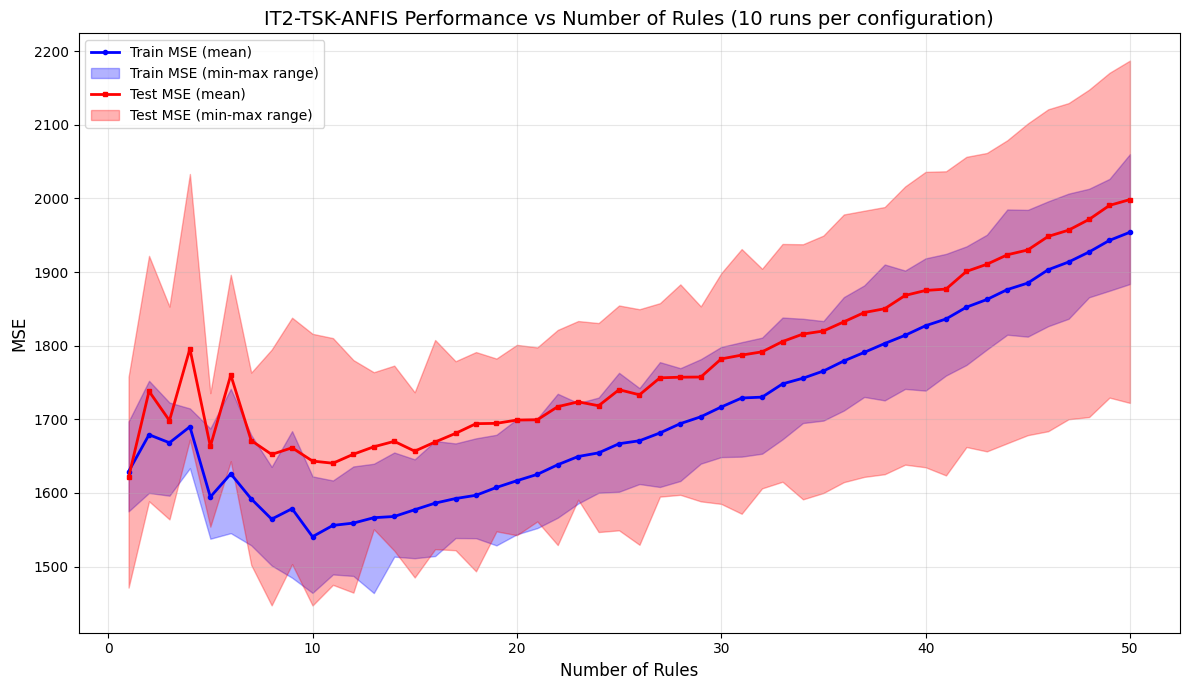


Best configuration: 1 rules with average test MSE: 1621.1048
At best config - Train MSE: 1629.1393

Top 5 configurations by test MSE:
1. n_rules= 1 | Test MSE: 1621.1048 ± 78.5097 | Train MSE: 1629.1393
2. n_rules=11 | Test MSE: 1640.3893 ± 95.2247 | Train MSE: 1555.9811
3. n_rules=10 | Test MSE: 1643.3295 ± 101.0182 | Train MSE: 1540.6284
4. n_rules= 8 | Test MSE: 1652.3559 ± 102.1570 | Train MSE: 1564.5171
5. n_rules=12 | Test MSE: 1652.6058 ± 89.6647 | Train MSE: 1559.1016


In [91]:
    
    # ==================== PLOTTING SECTION ====================
    print("\n" + "="*60)
    print("Creating plots...")
    print("="*60)
    
    n_rules_list = results['n_rules']
    
    # Create plot
    plt.figure(figsize=(12, 7))
    
    # Plot train MSE
    plt.plot(n_rules_list, results['train_mse_mean'], 'b-', linewidth=2, 
             label='Train MSE (mean)', marker='o', markersize=3)
    plt.fill_between(n_rules_list, results['train_mse_min'], results['train_mse_max'], 
                     alpha=0.3, color='blue', label='Train MSE (min-max range)')
    
    # Plot test MSE
    plt.plot(n_rules_list, results['test_mse_mean'], 'r-', linewidth=2, 
             label='Test MSE (mean)', marker='s', markersize=3)
    plt.fill_between(n_rules_list, results['test_mse_min'], results['test_mse_max'], 
                     alpha=0.3, color='red', label='Test MSE (min-max range)')
    
    plt.xlabel('Number of Rules', fontsize=12)
    plt.ylabel('MSE', fontsize=12)
    plt.title('IT2-TSK-ANFIS Performance vs Number of Rules (10 runs per configuration)', fontsize=14)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('it2_anfis_rules_vs_mse.png', dpi=300, bbox_inches='tight')
    print("Plot saved as 'it2_anfis_rules_vs_mse.png'")
    plt.show()
    
    # Print best configuration
    best_test_idx = np.argmin(results['test_mse_mean'])
    best_n_rules = results['n_rules'][best_test_idx]
    best_test_mse = results['test_mse_mean'][best_test_idx]
    print(f"\nBest configuration: {best_n_rules} rules with average test MSE: {best_test_mse:.4f}")
    print(f"At best config - Train MSE: {results['train_mse_mean'][best_test_idx]:.4f}")
    
    # Additional analysis: Top 5 configurations
    print("\n" + "="*60)
    print("Top 5 configurations by test MSE:")
    print("="*60)
    sorted_indices = np.argsort(results['test_mse_mean'])
    for i, idx in enumerate(sorted_indices[:5], 1):
        n_r = results['n_rules'][idx]
        test = results['test_mse_mean'][idx]
        train = results['train_mse_mean'][idx]
        print(f"{i}. n_rules={n_r:2d} | Test MSE: {test:.4f} ± {results['test_mse_std'][idx]:.4f} | Train MSE: {train:.4f}")

### ANFIS vs IT2ANFIS 


Creating combined subplot figure...
Plot saved as 'anfis_vs_it2_anfis_rules_vs_mse.png'


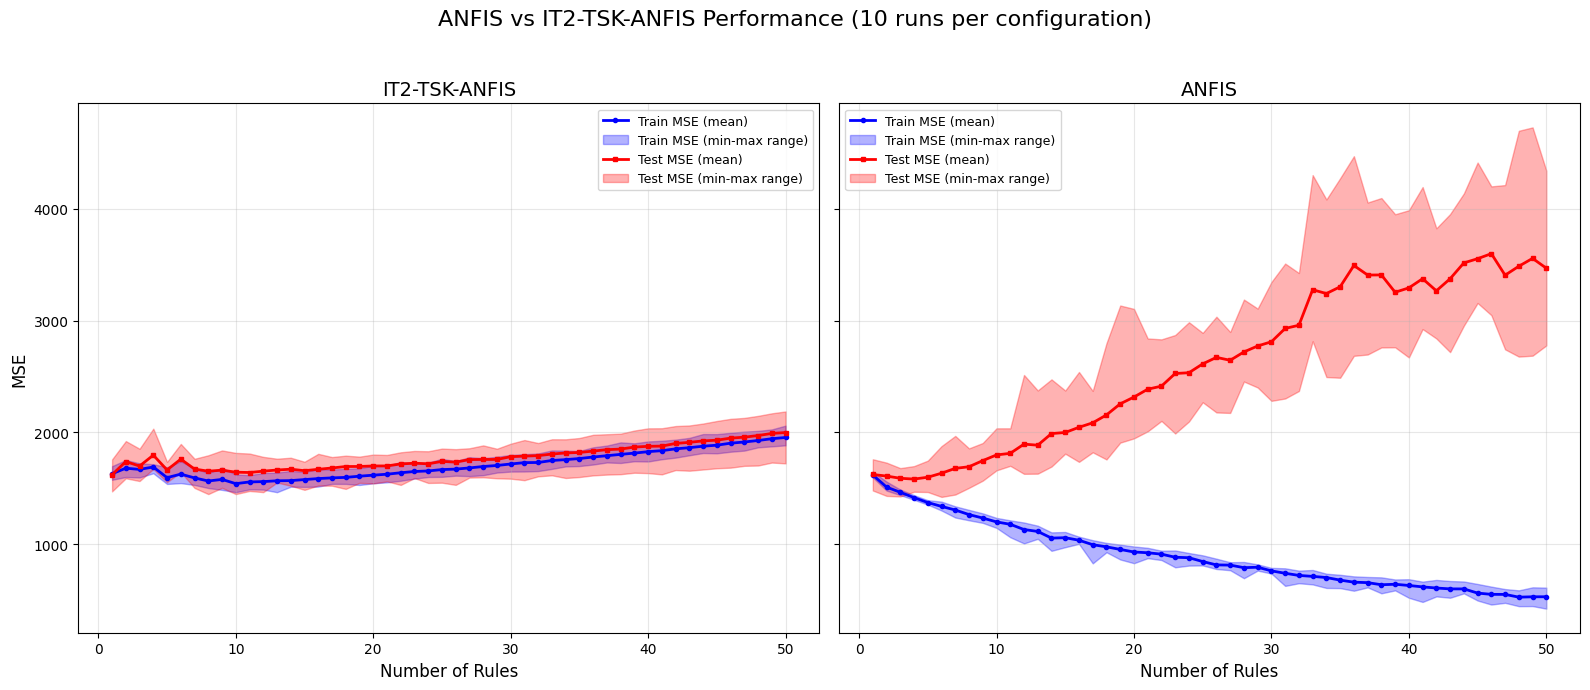

In [92]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ==================== LOAD RESULTS ====================
with open('anfis_results.pkl', 'rb') as f:
    anfis_results = pickle.load(f)

with open('it2_anfis_results.pkl', 'rb') as f:
    it2_results = pickle.load(f)

# ==================== PLOTTING SECTION ====================
print("\n" + "="*60)
print("Creating combined subplot figure...")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# ---------- Left subplot: IT2-TSK-ANFIS ----------
ax = axes[0]
n_rules_it2 = it2_results['n_rules']

ax.plot(n_rules_it2, it2_results['train_mse_mean'], 'b-', linewidth=2,
        label='Train MSE (mean)', marker='o', markersize=3)
ax.fill_between(n_rules_it2, it2_results['train_mse_min'], it2_results['train_mse_max'],
                alpha=0.3, color='blue', label='Train MSE (min-max range)')

ax.plot(n_rules_it2, it2_results['test_mse_mean'], 'r-', linewidth=2,
        label='Test MSE (mean)', marker='s', markersize=3)
ax.fill_between(n_rules_it2, it2_results['test_mse_min'], it2_results['test_mse_max'],
                alpha=0.3, color='red', label='Test MSE (min-max range)')

ax.set_xlabel('Number of Rules', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('IT2-TSK-ANFIS', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)


# ---------- Right subplot: ANFIS ----------
ax = axes[1]
n_rules_anfis = anfis_results['n_rules']

ax.plot(n_rules_anfis, anfis_results['train_mse_mean'], 'b-', linewidth=2,
        label='Train MSE (mean)', marker='o', markersize=3)
ax.fill_between(n_rules_anfis, anfis_results['train_mse_min'], anfis_results['train_mse_max'],
                alpha=0.3, color='blue', label='Train MSE (min-max range)')

ax.plot(n_rules_anfis, anfis_results['test_mse_mean'], 'r-', linewidth=2,
        label='Test MSE (mean)', marker='s', markersize=3)
ax.fill_between(n_rules_anfis, anfis_results['test_mse_min'], anfis_results['test_mse_max'],
                alpha=0.3, color='red', label='Test MSE (min-max range)')

ax.set_xlabel('Number of Rules', fontsize=12)
ax.set_title('ANFIS', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)


# ---------- Final layout ----------
fig.suptitle('ANFIS vs IT2-TSK-ANFIS Performance (10 runs per configuration)', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('anfis_vs_it2_anfis_rules_vs_mse.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'anfis_vs_it2_anfis_rules_vs_mse.png'")

plt.show()


Creating combined single-plot figure...
Plots saved:
  - PNG (600 dpi): 'anfis_vs_it2_anfis_rules_vs_mse_single_plot.png'
  - PDF (vector): 'anfis_vs_it2_anfis_rules_vs_mse_single_plot.pdf'


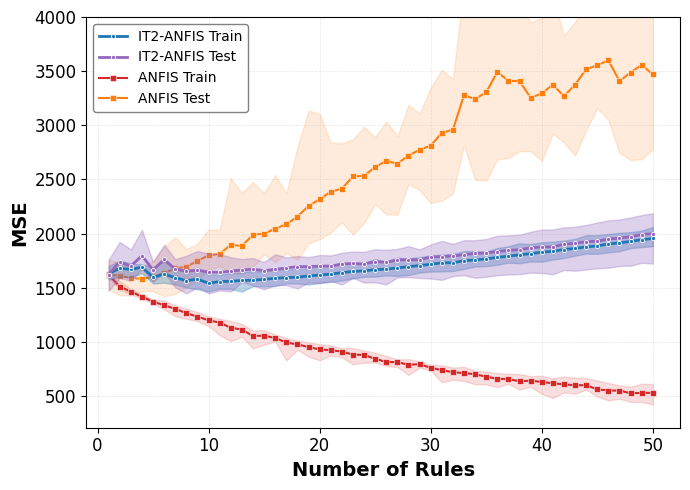

In [145]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ==================== LOAD RESULTS ====================
with open('anfis_results.pkl', 'rb') as f:
    anfis_results = pickle.load(f)

with open('it2_anfis_results.pkl', 'rb') as f:
    it2_results = pickle.load(f)

# ==================== PLOTTING SECTION ====================
print("\n" + "="*60)
print("Creating combined single-plot figure...")
print("="*60)

# Optimized figure size for single-column paper (typically 3.5 inches wide)
plt.figure(figsize=(7, 5))

# ---------- ANFIS First (Squares, Red/Orange colors) - Plot behind ----------
n_rules_anfis = anfis_results['n_rules']

plt.fill_between(n_rules_anfis,
                 anfis_results['train_mse_min'],
                 anfis_results['train_mse_max'],
                 color='#d62728', alpha=0.15, zorder=1)

plt.fill_between(n_rules_anfis,
                 anfis_results['test_mse_min'],
                 anfis_results['test_mse_max'],
                 color='#ff7f0e', alpha=0.15, zorder=1)

plt.plot(n_rules_anfis, anfis_results['train_mse_mean'],
         color='#d62728', linewidth=1.5, marker='s', markersize=4,
         label='ANFIS Train', markeredgewidth=0.4, markeredgecolor='white',
         zorder=2)

plt.plot(n_rules_anfis, anfis_results['test_mse_mean'],
         color='#ff7f0e', linewidth=1.5, marker='s', markersize=4,
         label='ANFIS Test', markeredgewidth=0.4, markeredgecolor='white',
         zorder=2)

# ---------- IT2-TSK-ANFIS On Top (Circles, Blue/Purple colors) ----------
n_rules_it2 = it2_results['n_rules']

plt.fill_between(n_rules_it2,
                 it2_results['train_mse_min'],
                 it2_results['train_mse_max'],
                 color='#1f77b4', alpha=0.3, zorder=3)

plt.fill_between(n_rules_it2,
                 it2_results['test_mse_min'],
                 it2_results['test_mse_max'],
                 color='#9467bd', alpha=0.3, zorder=3)

plt.plot(n_rules_it2, it2_results['train_mse_mean'],
         color='#1f77b4', linewidth=2.0, marker='o', markersize=3,
         label='IT2-ANFIS Train', markeredgewidth=0.6, markeredgecolor='white',
         zorder=4)

plt.plot(n_rules_it2, it2_results['test_mse_mean'],
         color='#9467bd', linewidth=2.0, marker='o', markersize=3,
         label='IT2-ANFIS Test', markeredgewidth=0.6, markeredgecolor='white',
         zorder=4)

# ---------- Enhanced Formatting for Publication ----------
plt.xlabel('Number of Rules', fontsize=14, fontweight='bold')
plt.ylabel('MSE', fontsize=14, fontweight='bold')
plt.ylim(top=4000)
plt.xlim(left=-1)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, zorder=0)

# Legend ordering
handles, labels = plt.gca().get_legend_handles_labels()
order = [2, 3, 0, 1]
plt.legend([handles[i] for i in order], [labels[i] for i in order],
           fontsize=10, loc='upper left', framealpha=0.98,
           edgecolor='gray', fancybox=True, shadow=False)

plt.tight_layout()

plt.savefig('anfis_vs_it2_anfis_rules_vs_mse_single_plot.png',
            dpi=600, bbox_inches='tight')
plt.savefig('anfis_vs_it2_anfis_rules_vs_mse_single_plot.pdf',
            bbox_inches='tight')

print("Plots saved:")
print("  - PNG (600 dpi): 'anfis_vs_it2_anfis_rules_vs_mse_single_plot.png'")
print("  - PDF (vector): 'anfis_vs_it2_anfis_rules_vs_mse_single_plot.pdf'")

plt.show()

In [146]:
import pickle
import numpy as np

# Load results
with open('anfis_results.pkl', 'rb') as f:
    anfis_results = pickle.load(f)

with open('it2_anfis_results.pkl', 'rb') as f:
    it2_results = pickle.load(f)

TARGET_RULES = 7

def get_test_mse(results, target_rules):
    idx = np.where(np.array(results['n_rules']) == target_rules)[0]
    if len(idx) == 0:
        raise ValueError(f"Number of rules = {target_rules} not found.")
    idx = idx[0]
    return results['test_mse_mean'][idx]

anfis_test_mse = get_test_mse(anfis_results, TARGET_RULES)
it2_test_mse   = get_test_mse(it2_results, TARGET_RULES)

print(f"Test MSE at {TARGET_RULES} rules:")
print(f"  ANFIS     : {anfis_test_mse:.6f}")
print(f"  IT2-ANFIS : {it2_test_mse:.6f}")

Test MSE at 7 rules:
  ANFIS     : 1677.462743
  IT2-ANFIS : 1671.206557



Creating camera-ready figure with zoomed inset...
Camera-ready plots saved:
  - PNG (600 dpi): 'anfis_vs_it2_anfis_with_zoom.png'
  - PDF (vector): 'anfis_vs_it2_anfis_with_zoom.pdf'


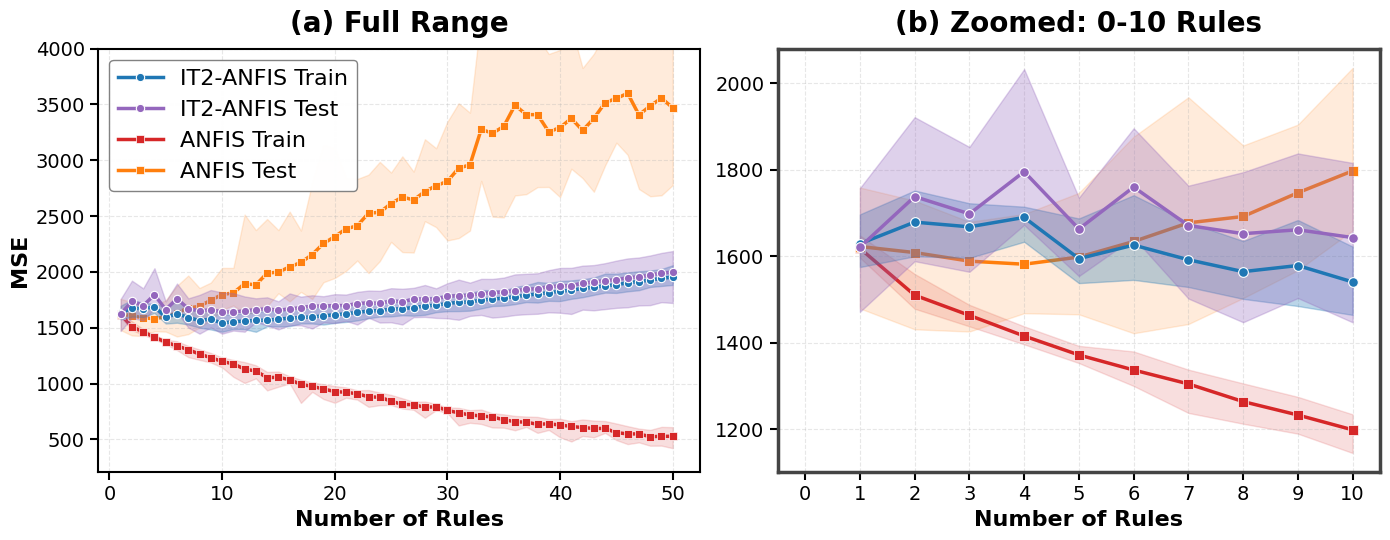

In [111]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ==================== LOAD RESULTS ====================
with open('anfis_results.pkl', 'rb') as f:
    anfis_results = pickle.load(f)

with open('it2_anfis_results.pkl', 'rb') as f:
    it2_results = pickle.load(f)

# ==================== PLOTTING SECTION ====================
print("\n" + "="*60)
print("Creating camera-ready figure with zoomed inset...")
print("="*60)

# Create figure with two subplots side by side
fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5.5))

# Convert to numpy arrays if they're lists
n_rules_anfis = np.array(anfis_results['n_rules'])
n_rules_it2 = np.array(it2_results['n_rules'])

train_mse_mean_anfis = np.array(anfis_results['train_mse_mean'])
train_mse_min_anfis = np.array(anfis_results['train_mse_min'])
train_mse_max_anfis = np.array(anfis_results['train_mse_max'])
test_mse_mean_anfis = np.array(anfis_results['test_mse_mean'])
test_mse_min_anfis = np.array(anfis_results['test_mse_min'])
test_mse_max_anfis = np.array(anfis_results['test_mse_max'])

train_mse_mean_it2 = np.array(it2_results['train_mse_mean'])
train_mse_min_it2 = np.array(it2_results['train_mse_min'])
train_mse_max_it2 = np.array(it2_results['train_mse_max'])
test_mse_mean_it2 = np.array(it2_results['test_mse_mean'])
test_mse_min_it2 = np.array(it2_results['test_mse_min'])
test_mse_max_it2 = np.array(it2_results['test_mse_max'])

# ==================== MAIN PLOT (LEFT) ====================
# ---------- ANFIS First (Squares, Red/Orange colors) - Plot behind ----------
ax_main.fill_between(n_rules_anfis,
                      train_mse_min_anfis,
                      train_mse_max_anfis,
                      color='#d62728', alpha=0.15, zorder=1)

ax_main.fill_between(n_rules_anfis,
                      test_mse_min_anfis,
                      test_mse_max_anfis,
                      color='#ff7f0e', alpha=0.15, zorder=1)

ax_main.plot(n_rules_anfis, train_mse_mean_anfis,
             color='#d62728', linewidth=2.5, marker='s', markersize=6,
             label='ANFIS Train', markeredgewidth=0.5, markeredgecolor='white',
             zorder=2)

ax_main.plot(n_rules_anfis, test_mse_mean_anfis,
             color='#ff7f0e', linewidth=2.5, marker='s', markersize=6,
             label='ANFIS Test', markeredgewidth=0.5, markeredgecolor='white',
             zorder=2)

# ---------- IT2-TSK-ANFIS On Top (Circles, Blue/Purple colors) ----------
ax_main.fill_between(n_rules_it2,
                      train_mse_min_it2,
                      train_mse_max_it2,
                      color='#1f77b4', alpha=0.3, zorder=3)

ax_main.fill_between(n_rules_it2,
                      test_mse_min_it2,
                      test_mse_max_it2,
                      color='#9467bd', alpha=0.3, zorder=3)

ax_main.plot(n_rules_it2, train_mse_mean_it2,
             color='#1f77b4', linewidth=2.5, marker='o', markersize=6,
             label='IT2-ANFIS Train', markeredgewidth=0.8, markeredgecolor='white',
             zorder=4)

ax_main.plot(n_rules_it2, test_mse_mean_it2,
             color='#9467bd', linewidth=2.5, marker='o', markersize=6,
             label='IT2-ANFIS Test', markeredgewidth=0.8, markeredgecolor='white',
             zorder=4)

# Main plot formatting
ax_main.set_xlabel('Number of Rules', fontsize=16, fontweight='bold')
ax_main.set_ylabel('MSE', fontsize=16, fontweight='bold')
ax_main.set_ylim(top=4000)
ax_main.set_xlim(left=-1)
ax_main.tick_params(axis='both', labelsize=14, width=1.5, length=6)
ax_main.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)

# Thicker spines for main plot
for spine in ax_main.spines.values():
    spine.set_linewidth(1.5)

# Legend for main plot
handles, labels = ax_main.get_legend_handles_labels()
order = [2, 3, 0, 1]
ax_main.legend([handles[i] for i in order], [labels[i] for i in order],
               fontsize=16, loc='upper left', framealpha=0.98,
               edgecolor='gray', fancybox=True, shadow=False)

ax_main.set_title('(a) Full Range', fontsize=20, fontweight='bold', pad=12)

# ==================== ZOOMED PLOT (RIGHT) ====================
# Filter data for x-axis range 0-10
mask_anfis = n_rules_anfis <= 10
mask_it2 = n_rules_it2 <= 10

# ---------- ANFIS (zoomed) ----------
ax_zoom.fill_between(n_rules_anfis[mask_anfis],
                      train_mse_min_anfis[mask_anfis],
                      train_mse_max_anfis[mask_anfis],
                      color='#d62728', alpha=0.15, zorder=1)

ax_zoom.fill_between(n_rules_anfis[mask_anfis],
                      test_mse_min_anfis[mask_anfis],
                      test_mse_max_anfis[mask_anfis],
                      color='#ff7f0e', alpha=0.15, zorder=1)

ax_zoom.plot(n_rules_anfis[mask_anfis], train_mse_mean_anfis[mask_anfis],
             color='#d62728', linewidth=2.5, marker='s', markersize=7,
             label='ANFIS Train', markeredgewidth=0.5, markeredgecolor='white',
             zorder=2)

ax_zoom.plot(n_rules_anfis[mask_anfis], test_mse_mean_anfis[mask_anfis],
             color='#ff7f0e', linewidth=2.5, marker='s', markersize=7,
             label='ANFIS Test', markeredgewidth=0.5, markeredgecolor='white',
             zorder=2)

# ---------- IT2-TSK-ANFIS (zoomed) ----------
ax_zoom.fill_between(n_rules_it2[mask_it2],
                      train_mse_min_it2[mask_it2],
                      train_mse_max_it2[mask_it2],
                      color='#1f77b4', alpha=0.3, zorder=3)

ax_zoom.fill_between(n_rules_it2[mask_it2],
                      test_mse_min_it2[mask_it2],
                      test_mse_max_it2[mask_it2],
                      color='#9467bd', alpha=0.3, zorder=3)

ax_zoom.plot(n_rules_it2[mask_it2], train_mse_mean_it2[mask_it2],
             color='#1f77b4', linewidth=2.5, marker='o', markersize=7,
             label='IT2-ANFIS Train', markeredgewidth=0.8, markeredgecolor='white',
             zorder=4)

ax_zoom.plot(n_rules_it2[mask_it2], test_mse_mean_it2[mask_it2],
             color='#9467bd', linewidth=2.5, marker='o', markersize=7,
             label='IT2-ANFIS Test', markeredgewidth=0.8, markeredgecolor='white',
             zorder=4)

# Zoomed plot formatting
ax_zoom.set_xlabel('Number of Rules', fontsize=16, fontweight='bold')
# No y-label for zoomed plot (share with main plot)
ax_zoom.set_xlim(-0.5, 10.5)

# Set x-axis ticks with increment of 1
ax_zoom.set_xticks(np.arange(0, 11, 1))
ax_zoom.tick_params(axis='both', labelsize=14, width=1.5, length=6)
ax_zoom.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)
ax_zoom.set_title('(b) Zoomed: 0-10 Rules', fontsize=20, fontweight='bold', pad=12)

# Thicker border to emphasize zoomed region
for spine in ax_zoom.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color('#444444')

plt.tight_layout()

plt.savefig('anfis_vs_it2_anfis_with_zoom.png',
            dpi=600, bbox_inches='tight')
plt.savefig('anfis_vs_it2_anfis_with_zoom.pdf',
            bbox_inches='tight')

print("Camera-ready plots saved:")
print("  - PNG (600 dpi): 'anfis_vs_it2_anfis_with_zoom.png'")
print("  - PDF (vector): 'anfis_vs_it2_anfis_with_zoom.pdf'")

plt.show()

## IT-ANFIS Final model with 7 Rules


Initializing IT2-TSK-ANFIS with Grid Partitioning...
Initializing with grid partitioning...
Using random grid sampling (uniform grid would create 8192 rules)
Initialized 7 rules with random grid sampling
Average FOU width: 0.6904

Training model...

Training Configuration:
  Batch size: 64
  Batches per epoch: 13
  L1 regularization: 0.05
  L2 regularization: 0.001
  Antecedents: Trainable
  Early stopping patience: 40

Epoch   1 | Train MSE: 48424.266293 | Val MSE: 49447.099183 | η_cons: 0.030000 | η_ant: 0.030000
Epoch   2 | Train MSE: 30307.685824 | Val MSE: 30997.854196 | η_cons: 0.031500 | η_ant: 0.020000
Epoch   3 | Train MSE: 19206.522294 | Val MSE: 19806.931448 | η_cons: 0.033075 | η_ant: 0.020000
Epoch   4 | Train MSE: 12444.759589 | Val MSE: 13045.490419 | η_cons: 0.034729 | η_ant: 0.020000
Epoch   5 | Train MSE: 8414.742821 | Val MSE: 9038.420617 | η_cons: 0.036465 | η_ant: 0.020000
Epoch   6 | Train MSE: 5974.403216 | Val MSE: 6590.790527 | η_cons: 0.038288 | η_ant: 0.0200

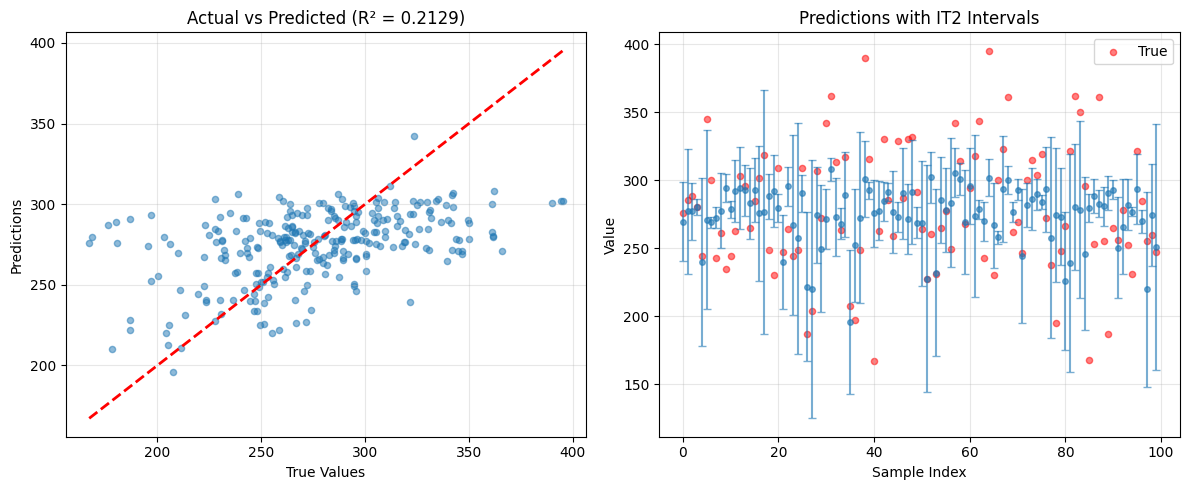


Explaining prediction for first test sample:
Input sample 1: [-0.76113499 -0.18248943  0.53053788  0.63322808  0.54575667  1.55507628
  1.64233111  0.41076038 -0.3540434   0.30927441  0.46006543  1.42419075
  0.67117195]
Predicted value: 269.6484
Prediction interval: [298.4113, 240.8856]
Confidence (inverse of interval width): -0.0174

Rule contributions:
  Rule 1:
    Normalized Firing Strengths -> lower: 0.000, upper: 0.000
    Rule output contribution -> lower: -0.000, upper: -0.000
    Rule FOU (uncertainty) width: 0.426
  Rule 2:
    Normalized Firing Strengths -> lower: 0.000, upper: 0.000
    Rule output contribution -> lower: -0.000, upper: -0.032
    Rule FOU (uncertainty) width: 1.117
  Rule 3:
    Normalized Firing Strengths -> lower: 0.614, upper: 0.124
    Rule output contribution -> lower: 208.696, upper: 42.038
    Rule FOU (uncertainty) width: 0.639
  Rule 4:
    Normalized Firing Strengths -> lower: 0.385, upper: 0.851
    Rule output contribution -> lower: 89.700, up

In [ ]:
# final model with 7 rules only but better performance due to better hyperparameters
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import torch  # Added for autodiff-based antecedent updates

class IT2_TSK_ANFIS:
    """
    Improved Interval Type-2 TSK Fuzzy Neural System with:
    - Grid-based initialization
    - Separate learning rates for antecedents and consequents
    - Stronger regularization (L1 + L2)
    - Improved early stopping with model checkpointing
    - Mini-batch training

    NOTE: Finite-difference antecedent updates have been replaced with
    PyTorch autodiff-based analytical gradients (only change requested).
    """

    def __init__(self, n_rules, X, m1=1.5, m2=3.0, min_sigma=0.05):
        self.n_rules = n_rules
        self.n_features = X.shape[1]
        self.min_sigma = min_sigma
        self.m1 = m1
        self.m2 = m2

        # Initialize using grid partitioning
        print("Initializing with grid partitioning...")
        self._init_with_grid(X)

        # TSK consequent parameters
        self.w = np.random.randn(self.n_rules, self.n_features) * 0.01  # Smaller initialization
        self.b = np.random.randn(self.n_rules) * 0.01

        # Design factor q
        self.q = 0.5

        # Separate adaptive learning rates
        self.eta_consequent = 0.03
        self.eta_antecedent = 0.03  # Much smaller for antecedents
        self.prev_error = np.inf
        
        # Best model storage
        self.best_w = None
        self.best_b = None
        self.best_c1 = None
        self.best_c2 = None

    # ---------------- Grid-Based Initialization ----------------
    def _init_with_grid(self, X):
        """
        Initialize fuzzy sets using grid partitioning.
        Uses adaptive strategy: uniform grid for low dimensions, 
        random sampling for high dimensions.
        """
        N = X.shape[0]
        
        # For high-dimensional spaces, use random sampling instead of full grid
        # Threshold: if uniform grid would create more than 2x requested rules, use random sampling
        rules_per_dim = max(2, int(np.ceil(self.n_rules ** (1.0 / self.n_features))))
        potential_rules = rules_per_dim ** self.n_features
        
        if potential_rules > 2 * self.n_rules or self.n_features > 8:
            # Use random/hybrid approach for high dimensions
            print(f"Using random grid sampling (uniform grid would create {potential_rules} rules)")
            self._init_with_random_grid(X)
            return
        
        # Use uniform grid for low dimensions
        if potential_rules != self.n_rules:
            print(f"Adjusting rules from {self.n_rules} to {potential_rules} for uniform grid")
            self.n_rules = potential_rules
        
        # Get feature ranges
        feature_mins = X.min(axis=0)
        feature_maxs = X.max(axis=0)
        feature_ranges = feature_maxs - feature_mins
        
        # Create grid centers
        self.c1 = np.zeros((self.n_rules, self.n_features))
        self.c2 = np.zeros((self.n_rules, self.n_features))
        self.centers = np.zeros((self.n_rules, self.n_features))
        
        # Generate all combinations of grid points
        grid_indices = np.array(np.meshgrid(*[np.arange(rules_per_dim) for _ in range(self.n_features)])).T.reshape(-1, self.n_features)
        
        # Calculate partition width for each feature
        partition_widths = feature_ranges / rules_per_dim
        
        # Uncertainty factor (footprint of uncertainty width as percentage of partition)
        uncertainty_factor = 0.2  # 20% of partition width
        
        for rule_idx in range(self.n_rules):
            for feat_idx in range(self.n_features):
                # Center of this partition
                grid_pos = grid_indices[rule_idx, feat_idx]
                partition_center = feature_mins[feat_idx] + (grid_pos + 0.5) * partition_widths[feat_idx]
                
                # Footprint of uncertainty
                uncertainty_width = partition_widths[feat_idx] * uncertainty_factor
                
                self.c1[rule_idx, feat_idx] = partition_center - uncertainty_width / 2
                self.c2[rule_idx, feat_idx] = partition_center + uncertainty_width / 2
                self.centers[rule_idx, feat_idx] = partition_center
        
        # Calculate standard deviations based on partition widths
        self.stds = np.zeros((self.n_rules, self.n_features))
        for feat_idx in range(self.n_features):
            # Std covers approximately one partition width
            std_value = partition_widths[feat_idx] * 0.5
            self.stds[:, feat_idx] = max(std_value, self.min_sigma)
        
        print(f"Initialized {self.n_rules} rules with grid partitioning ({rules_per_dim} per dimension)")
        print(f"Average FOU width: {np.mean(self.c2 - self.c1):.4f}")

    def _init_with_random_grid(self, X):
        """
        Initialize with random grid sampling for high-dimensional spaces.
        Combines random center selection with grid-inspired uncertainty.
        """
        N = X.shape[0]
        
        # Get feature ranges
        feature_mins = X.min(axis=0)
        feature_maxs = X.max(axis=0)
        feature_ranges = feature_maxs - feature_mins
        
        self.c1 = np.zeros((self.n_rules, self.n_features))
        self.c2 = np.zeros((self.n_rules, self.n_features))
        self.centers = np.zeros((self.n_rules, self.n_features))
        self.stds = np.zeros((self.n_rules, self.n_features))
        
        # Estimate typical partition width (as if we divided space by cube root of rules)
        typical_partitions = int(np.ceil(self.n_rules ** (1.0 / self.n_features)))
        partition_widths = feature_ranges / typical_partitions
        uncertainty_factor = 0.2
        
        # Random sampling with Latin Hypercube for better coverage
        for rule_idx in range(self.n_rules):
            for feat_idx in range(self.n_features):
                # Sample center uniformly from feature range with stratification
                segment_size = feature_ranges[feat_idx] / self.n_rules
                segment_start = feature_mins[feat_idx] + rule_idx * segment_size
                segment_center = segment_start + np.random.uniform(0, segment_size)
                
                # Add uncertainty
                uncertainty_width = partition_widths[feat_idx] * uncertainty_factor
                
                self.c1[rule_idx, feat_idx] = segment_center - uncertainty_width / 2
                self.c2[rule_idx, feat_idx] = segment_center + uncertainty_width / 2
                self.centers[rule_idx, feat_idx] = segment_center
                
                # Standard deviation
                self.stds[rule_idx, feat_idx] = max(partition_widths[feat_idx] * 0.5, self.min_sigma)
        
        print(f"Initialized {self.n_rules} rules with random grid sampling")
        print(f"Average FOU width: {np.mean(self.c2 - self.c1):.4f}")

    # ---------------- Memberships and Firing Strengths ----------------
    def _compute_memberships(self, X):
        N = X.shape[0]
        mu_lower = np.zeros((N, self.n_rules))
        mu_upper = np.zeros((N, self.n_rules))

        for k in range(self.n_rules):
            mu_lower_feat = np.ones(N)
            mu_upper_feat = np.ones(N)
            for f in range(self.n_features):
                x_f = X[:, f]
                c1_kf = self.c1[k, f]
                c2_kf = self.c2[k, f]
                c_mid = (c1_kf + c2_kf) / 2
                sigma_kf = self.stds[k, f]

                mu_l = np.where(x_f <= c_mid,
                                np.exp(-0.5 * ((x_f - c2_kf) / sigma_kf) ** 2),
                                np.exp(-0.5 * ((x_f - c1_kf) / sigma_kf) ** 2))

                mu_u = np.where(x_f < c1_kf,
                                np.exp(-0.5 * ((x_f - c1_kf) / sigma_kf) ** 2),
                                np.where(x_f <= c2_kf,
                                         1.0,
                                         np.exp(-0.5 * ((x_f - c2_kf) / sigma_kf) ** 2)))

                mu_lower_feat *= mu_l
                mu_upper_feat *= mu_u

            mu_lower[:, k] = mu_lower_feat
            mu_upper[:, k] = mu_upper_feat

        return mu_lower, mu_upper

    def _compute_firing_strengths(self, X):
        f_lower, f_upper = self._compute_memberships(X)
        f_lower = np.maximum(f_lower, 1e-12)
        f_upper = np.maximum(f_upper, 1e-12)
        return f_lower, f_upper

    # ---------------- Output Computation ----------------
    def _compute_output(self, X, f_lower, f_upper):
        N = X.shape[0]
        y_consequents = X @ self.w.T + self.b
        sum_f_lower = f_lower.sum(axis=1, keepdims=True)
        sum_f_upper = f_upper.sum(axis=1, keepdims=True)
        f_lower_norm = f_lower / np.maximum(sum_f_lower, 1e-12)
        f_upper_norm = f_upper / np.maximum(sum_f_upper, 1e-12)
        u_lower = (f_lower_norm * y_consequents).sum(axis=1)
        u_upper = (f_upper_norm * y_consequents).sum(axis=1)
        u = self.q * u_lower + (1 - self.q) * u_upper
        return u, u_lower, u_upper, f_lower_norm, f_upper_norm, y_consequents

    # ---------------- Prediction Methods ----------------
    def predict(self, X):
        f_lower, f_upper = self._compute_firing_strengths(X)
        u, _, _, _, _, _ = self._compute_output(X, f_lower, f_upper)
        return u

    def predict_interval(self, X):
        f_lower, f_upper = self._compute_firing_strengths(X)
        _, u_lower, u_upper, _, _, _ = self._compute_output(X, f_lower, f_upper)
        return np.minimum(u_lower, u_upper), np.maximum(u_lower, u_upper)

    # ---------------- Training with Improvements ----------------
    def fit(self, X, y, X_val, y_val, epochs=100, patience=30, batch_size=64, 
            freeze_antecedents=True, lambda_l1=0.005, lambda_l2=0.01):
        """
        Train the IT2-TSK-ANFIS model with mini-batch gradient descent.
        
        Parameters:
        -----------
        freeze_antecedents : bool
            If True, only update consequent parameters (recommended for stability)
        lambda_l1 : float
            L1 regularization strength for sparsity
        lambda_l2 : float
            L2 regularization strength for weight decay
        """
        N = X.shape[0]
        n_batches = max(1, N // batch_size)
        best_val_mse = np.inf
        wait = 0
        min_delta = 0.01  # Minimum improvement threshold
        
        print(f"\nTraining Configuration:")
        print(f"  Batch size: {batch_size}")
        print(f"  Batches per epoch: {n_batches}")
        print(f"  L1 regularization: {lambda_l1}")
        print(f"  L2 regularization: {lambda_l2}")
        print(f"  Antecedents: {'Frozen' if freeze_antecedents else 'Trainable'}")
        print(f"  Early stopping patience: {patience}")
        print()

        for epoch in range(epochs):
            # Shuffle data for each epoch
            indices = np.random.permutation(N)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_train_loss = 0
            
            # Mini-batch training
            for batch in range(n_batches):
                start_idx = batch * batch_size
                end_idx = min(start_idx + batch_size, N)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                
                # Forward pass
                f_lower, f_upper = self._compute_firing_strengths(X_batch)
                u, u_lower, u_upper, f_l_norm, f_u_norm, y_cons = self._compute_output(X_batch, f_lower, f_upper)
                error = u - y_batch
                batch_mse = np.mean(error ** 2)
                epoch_train_loss += batch_mse
                
                # Update consequent parameters with L1 + L2 regularization
                for j in range(self.n_rules):
                    factor = (self.q * f_l_norm[:, j] / (f_l_norm.sum(axis=1) + 1e-12) +
                             (1 - self.q) * f_u_norm[:, j] / (f_u_norm.sum(axis=1) + 1e-12))
                    
                    grad_w = (error[:, None] * factor[:, None] * X_batch).mean(axis=0)
                    grad_b = (error * factor).mean()
                    
                    # Apply L1 and L2 regularization
                    grad_w += lambda_l2 * self.w[j] + lambda_l1 * np.sign(self.w[j])
                    grad_b += lambda_l2 * self.b[j] + lambda_l1 * np.sign(self.b[j])
                    
                    # Gradient descent update
                    self.w[j] -= self.eta_consequent * grad_w
                    self.b[j] -= self.eta_consequent * grad_b
            
            # Calculate epoch metrics
            train_mse = epoch_train_loss / n_batches
            val_pred = self.predict(X_val)
            val_mse = mean_squared_error(y_val, val_pred)
            
            # Compute full training set prediction for monitoring
            train_pred = self.predict(X)
            train_mse_full = mean_squared_error(y, train_pred)
            
            if epoch % 5 == 0 or epoch < 10:
                print(f"Epoch {epoch+1:3d} | Train MSE: {train_mse_full:.6f} | Val MSE: {val_mse:.6f} | "
                      f"η_cons: {self.eta_consequent:.6f} | η_ant: {self.eta_antecedent:.6f}")
            
            # Fix q to 0.5 (as in original)
            self.q = 0.5
            
            # ----------------- Antecedent update: replaced FD by PyTorch autodiff -----------------
            # Update antecedents (only if not frozen, and only every 10 epochs for stability)
            if not freeze_antecedents:
                # Use PyTorch autograd to compute analytical gradients wrt c1 and c2 for the full training set
                # Convert numpy arrays to torch tensors (CPU) for autodiff
                X_t = torch.tensor(X, dtype=torch.float32)              # shape (N, F)
                y_t = torch.tensor(y, dtype=torch.float32)              # shape (N,)
                w_t = torch.tensor(self.w.astype(np.float32), requires_grad=False)  # shape (R, F)
                b_t = torch.tensor(self.b.astype(np.float32), requires_grad=False)  # shape (R,)
                c1_t = torch.tensor(self.c1.astype(np.float32), requires_grad=True) # shape (R, F)
                c2_t = torch.tensor(self.c2.astype(np.float32), requires_grad=True) # shape (R, F)
                stds_t = torch.tensor(self.stds.astype(np.float32), requires_grad=False) # shape (R, F)
                q_t = float(self.q)

                # Expand dims to broadcast: X -> (N,1,F), c1/c2/stds -> (1,R,F)
                X_exp = X_t.unsqueeze(1)           # (N,1,F)
                c1_exp = c1_t.unsqueeze(0)         # (1,R,F)
                c2_exp = c2_t.unsqueeze(0)         # (1,R,F)
                mid_exp = 0.5 * (c1_exp + c2_exp)  # (1,R,F)
                stds_exp = stds_t.unsqueeze(0)     # (1,R,F)

                # lower membership mu_l (N,R,F) using the same piecewise Gaussian form
                # mu_l = exp(-0.5 * ((x - c2)/sigma)^2) if x <= mid else exp(-0.5 * ((x - c1)/sigma)^2)
                term_l_left = torch.exp(-0.5 * ((X_exp - c2_exp) / stds_exp) ** 2)
                term_l_right = torch.exp(-0.5 * ((X_exp - c1_exp) / stds_exp) ** 2)
                mu_l = torch.where(X_exp <= mid_exp, term_l_left, term_l_right)  # (N,R,F)

                # upper membership mu_u
                term_u_left = torch.exp(-0.5 * ((X_exp - c1_exp) / stds_exp) ** 2)
                term_u_right = torch.exp(-0.5 * ((X_exp - c2_exp) / stds_exp) ** 2)
                mu_u = torch.where(X_exp < c1_exp,
                                   term_u_left,
                                   torch.where(X_exp <= c2_exp,
                                               torch.ones_like(X_exp),
                                               term_u_right))  # (N,R,F)

                # product over features -> (N,R)
                mu_lower_t = torch.prod(mu_l, dim=2)  # (N,R)
                mu_upper_t = torch.prod(mu_u, dim=2)  # (N,R)

                # numerical stability
                mu_lower_t = torch.clamp(mu_lower_t, min=1e-12)
                mu_upper_t = torch.clamp(mu_upper_t, min=1e-12)

                # consequents y_cons: (N,R) where y_cons[n,r] = X[n,:] @ w[r,:].T + b[r]
                y_cons_t = torch.matmul(X_t, w_t.t()) + b_t.unsqueeze(0)  # (N,R)

                # normalize firing strengths
                sum_lower = mu_lower_t.sum(dim=1, keepdim=True)  # (N,1)
                sum_upper = mu_upper_t.sum(dim=1, keepdim=True)  # (N,1)
                f_lower_norm_t = mu_lower_t / torch.clamp(sum_lower, min=1e-12)
                f_upper_norm_t = mu_upper_t / torch.clamp(sum_upper, min=1e-12)

                u_lower_t = (f_lower_norm_t * y_cons_t).sum(dim=1)  # (N,)
                u_upper_t = (f_upper_norm_t * y_cons_t).sum(dim=1)  # (N,)
                u_t = q_t * u_lower_t + (1.0 - q_t) * u_upper_t     # (N,)

                # loss on full training set (consistent with FD approach used earlier)
                loss_t = torch.mean((u_t - y_t) ** 2)

                # Backprop to get gradients wrt c1_t and c2_t
                # Zero any existing gradients (safety)
                if c1_t.grad is not None:
                    c1_t.grad.zero_()
                if c2_t.grad is not None:
                    c2_t.grad.zero_()

                loss_t.backward()

                # Extract gradients and convert to numpy
                grad_c1 = c1_t.grad.detach().cpu().numpy()  # shape (R, F)
                grad_c2 = c2_t.grad.detach().cpu().numpy()  # shape (R, F)

                # Apply the same step-scaling and clipping as original FD code
                # Note: original FD code used: self.c1 -= self.eta_antecedent * 0.01 * np.clip(grad_c1, -0.1, 0.1)
                self.c1 -= self.eta_antecedent  * np.clip(grad_c1, -0.1, 0.1)
                self.c2 -= self.eta_antecedent  * np.clip(grad_c2, -0.1, 0.1)

                # Ensure min separation and ordering as before
                min_sep = 0.05
                for k in range(self.n_rules):
                    for f in range(self.n_features):
                        if self.c1[k, f] > self.c2[k, f]:
                            self.c1[k, f], self.c2[k, f] = self.c2[k, f], self.c1[k, f]
                        if (self.c2[k, f] - self.c1[k, f]) < min_sep:
                            mid = 0.5 * (self.c1[k, f] + self.c2[k, f])
                            self.c1[k, f] = mid - min_sep / 2
                            self.c2[k, f] = mid + min_sep / 2
                        self.centers[k, f] = 0.5 * (self.c1[k, f] + self.c2[k, f])
            # ----------------- End antecedent PyTorch update block -----------------

            # Adaptive learning rate with conservative caps
            delta_error = self.prev_error - train_mse_full
            if delta_error > 0:
                self.eta_consequent = min(self.eta_consequent * 1.05, 0.05)  # Cap at 0.05
                self.eta_antecedent = min(self.eta_antecedent * 1.05, 0.02)  # Cap at 0.005
            else:
                self.eta_consequent = max(self.eta_consequent * 0.9, 1e-5)
                self.eta_antecedent = max(self.eta_antecedent * 0.95, 1e-6)
            self.prev_error = train_mse_full
            
            # Improved early stopping with min_delta and model checkpointing
            if val_mse < (best_val_mse - min_delta):
                best_val_mse = val_mse
                wait = 0
                # Save best model
                self.best_w = self.w.copy()
                self.best_b = self.b.copy()
                self.best_c1 = self.c1.copy()
                self.best_c2 = self.c2.copy()
            else:
                wait += 1
                if wait >= patience:
                    print(f"\nEarly stopping at epoch {epoch+1}")
                    break
        
        # Restore best model
        if self.best_w is not None:
            print(f"\nRestoring best model from validation")
            self.w = self.best_w
            self.b = self.best_b
            self.c1 = self.best_c1
            self.c2 = self.best_c2
        
        print(f"Training completed. Best Val MSE: {best_val_mse:.6f}")

    def test(self, X, y):
        y_pred = self.predict(X)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        # MAPE calculation (avoid division by zero)
        mask = y != 0
        mape = np.mean(np.abs((y[mask] - y_pred[mask]) / y[mask])) * 100 if mask.any() else 0

        print(f"\n{'='*60}")
        print(f"Test Results:")
        print(f"  MSE:  {mse:.6f}")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE:  {mae:.6f}")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  R²:   {r2:.6f}")
        print(f"{'='*60}")

        y_lower, y_upper = self.predict_interval(X)
        avg_width = (y_upper - y_lower).mean()
        print(f"  Avg Interval Width: {avg_width:.6f}")

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].scatter(y, y_pred, alpha=0.5, s=20)
        axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
        axes[0].set_xlabel('True Values')
        axes[0].set_ylabel('Predictions')
        axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
        axes[0].grid(True, alpha=0.3)

        n_show = min(100, len(y))
        indices = np.arange(n_show)
        axes[1].errorbar(indices, y_pred[:n_show],
                        yerr=[y_pred[:n_show]-y_lower[:n_show], y_upper[:n_show]-y_pred[:n_show]],
                        fmt='o', alpha=0.6, capsize=3, markersize=4)
        axes[1].scatter(indices, y[:n_show], color='red', alpha=0.5, s=20, label='True')
        axes[1].set_xlabel('Sample Index')
        axes[1].set_ylabel('Value')
        axes[1].set_title('Predictions with IT2 Intervals')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return mse, rmse, mae, mape, r2

    # ---------------- Verbose Explanation ----------------
    def explain_prediction(self, X_input):
        X_input = np.atleast_2d(X_input)
        f_lower, f_upper = self._compute_firing_strengths(X_input)
        u, u_lower, u_upper, f_l_norm, f_u_norm, y_cons = self._compute_output(X_input, f_lower, f_upper)

        for i, x in enumerate(X_input):
            print("="*60)
            print(f"Input sample {i+1}: {x}")
            print(f"Predicted value: {u[i]:.4f}")
            print(f"Prediction interval: [{u_lower[i]:.4f}, {u_upper[i]:.4f}]")
            interval_width = u_upper[i] - u_lower[i]
            print(f"Confidence (inverse of interval width): {1/(interval_width+1e-8):.4f}")
            print("\nRule contributions:")
            for k in range(self.n_rules):
                contrib_lower = f_l_norm[i, k] * y_cons[i, k]
                contrib_upper = f_u_norm[i, k] * y_cons[i, k]
                fou_width = np.mean(self.c2[k] - self.c1[k])
                print(f"  Rule {k+1}:")
                print(f"    Normalized Firing Strengths -> lower: {f_l_norm[i, k]:.3f}, upper: {f_u_norm[i, k]:.3f}")
                print(f"    Rule output contribution -> lower: {contrib_lower:.3f}, upper: {contrib_upper:.3f}")
                print(f"    Rule FOU (uncertainty) width: {fou_width:.3f}")
            print("="*60)
            print("\n")


# ---------------- Main Pipeline ----------------
if __name__ == '__main__':
    # ---------------- Load features and target from df_final ----------------
    X = df_final.drop(columns=['Energy Consumption (MWh)']).values
    y = df_final['Energy Consumption (MWh)'].values

    # ---------------- Split into train, val, test ----------------
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=1)

    # ---------------- Scale features ----------------
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # ---------------- Initialize and train IT2-TSK-ANFIS ----------------
    print("\nInitializing IT2-TSK-ANFIS with Grid Partitioning...")
    
    # Start with 10-16 rules (good for 13 features with 1382 samples)
    # Will automatically switch to random sampling to avoid exponential explosion
    model = IT2_TSK_ANFIS(n_rules=7, X=X_tr, m1=1.5, m2=3.0)

    print("\nTraining model...")
    model.fit(X_tr, y_tr, X_val, y_val, 
              epochs=300, 
              patience=40, 
              batch_size=64,
              freeze_antecedents=False,  # Recommended for stability
              lambda_l1=0.05, 
              lambda_l2=0.001)

    print("\nEvaluating on test set...")
    model.test(X_test, y_test)

    # Verbose explanation for first test sample
    print("\nExplaining prediction for first test sample:")
    model.explain_prediction(X_test[0])


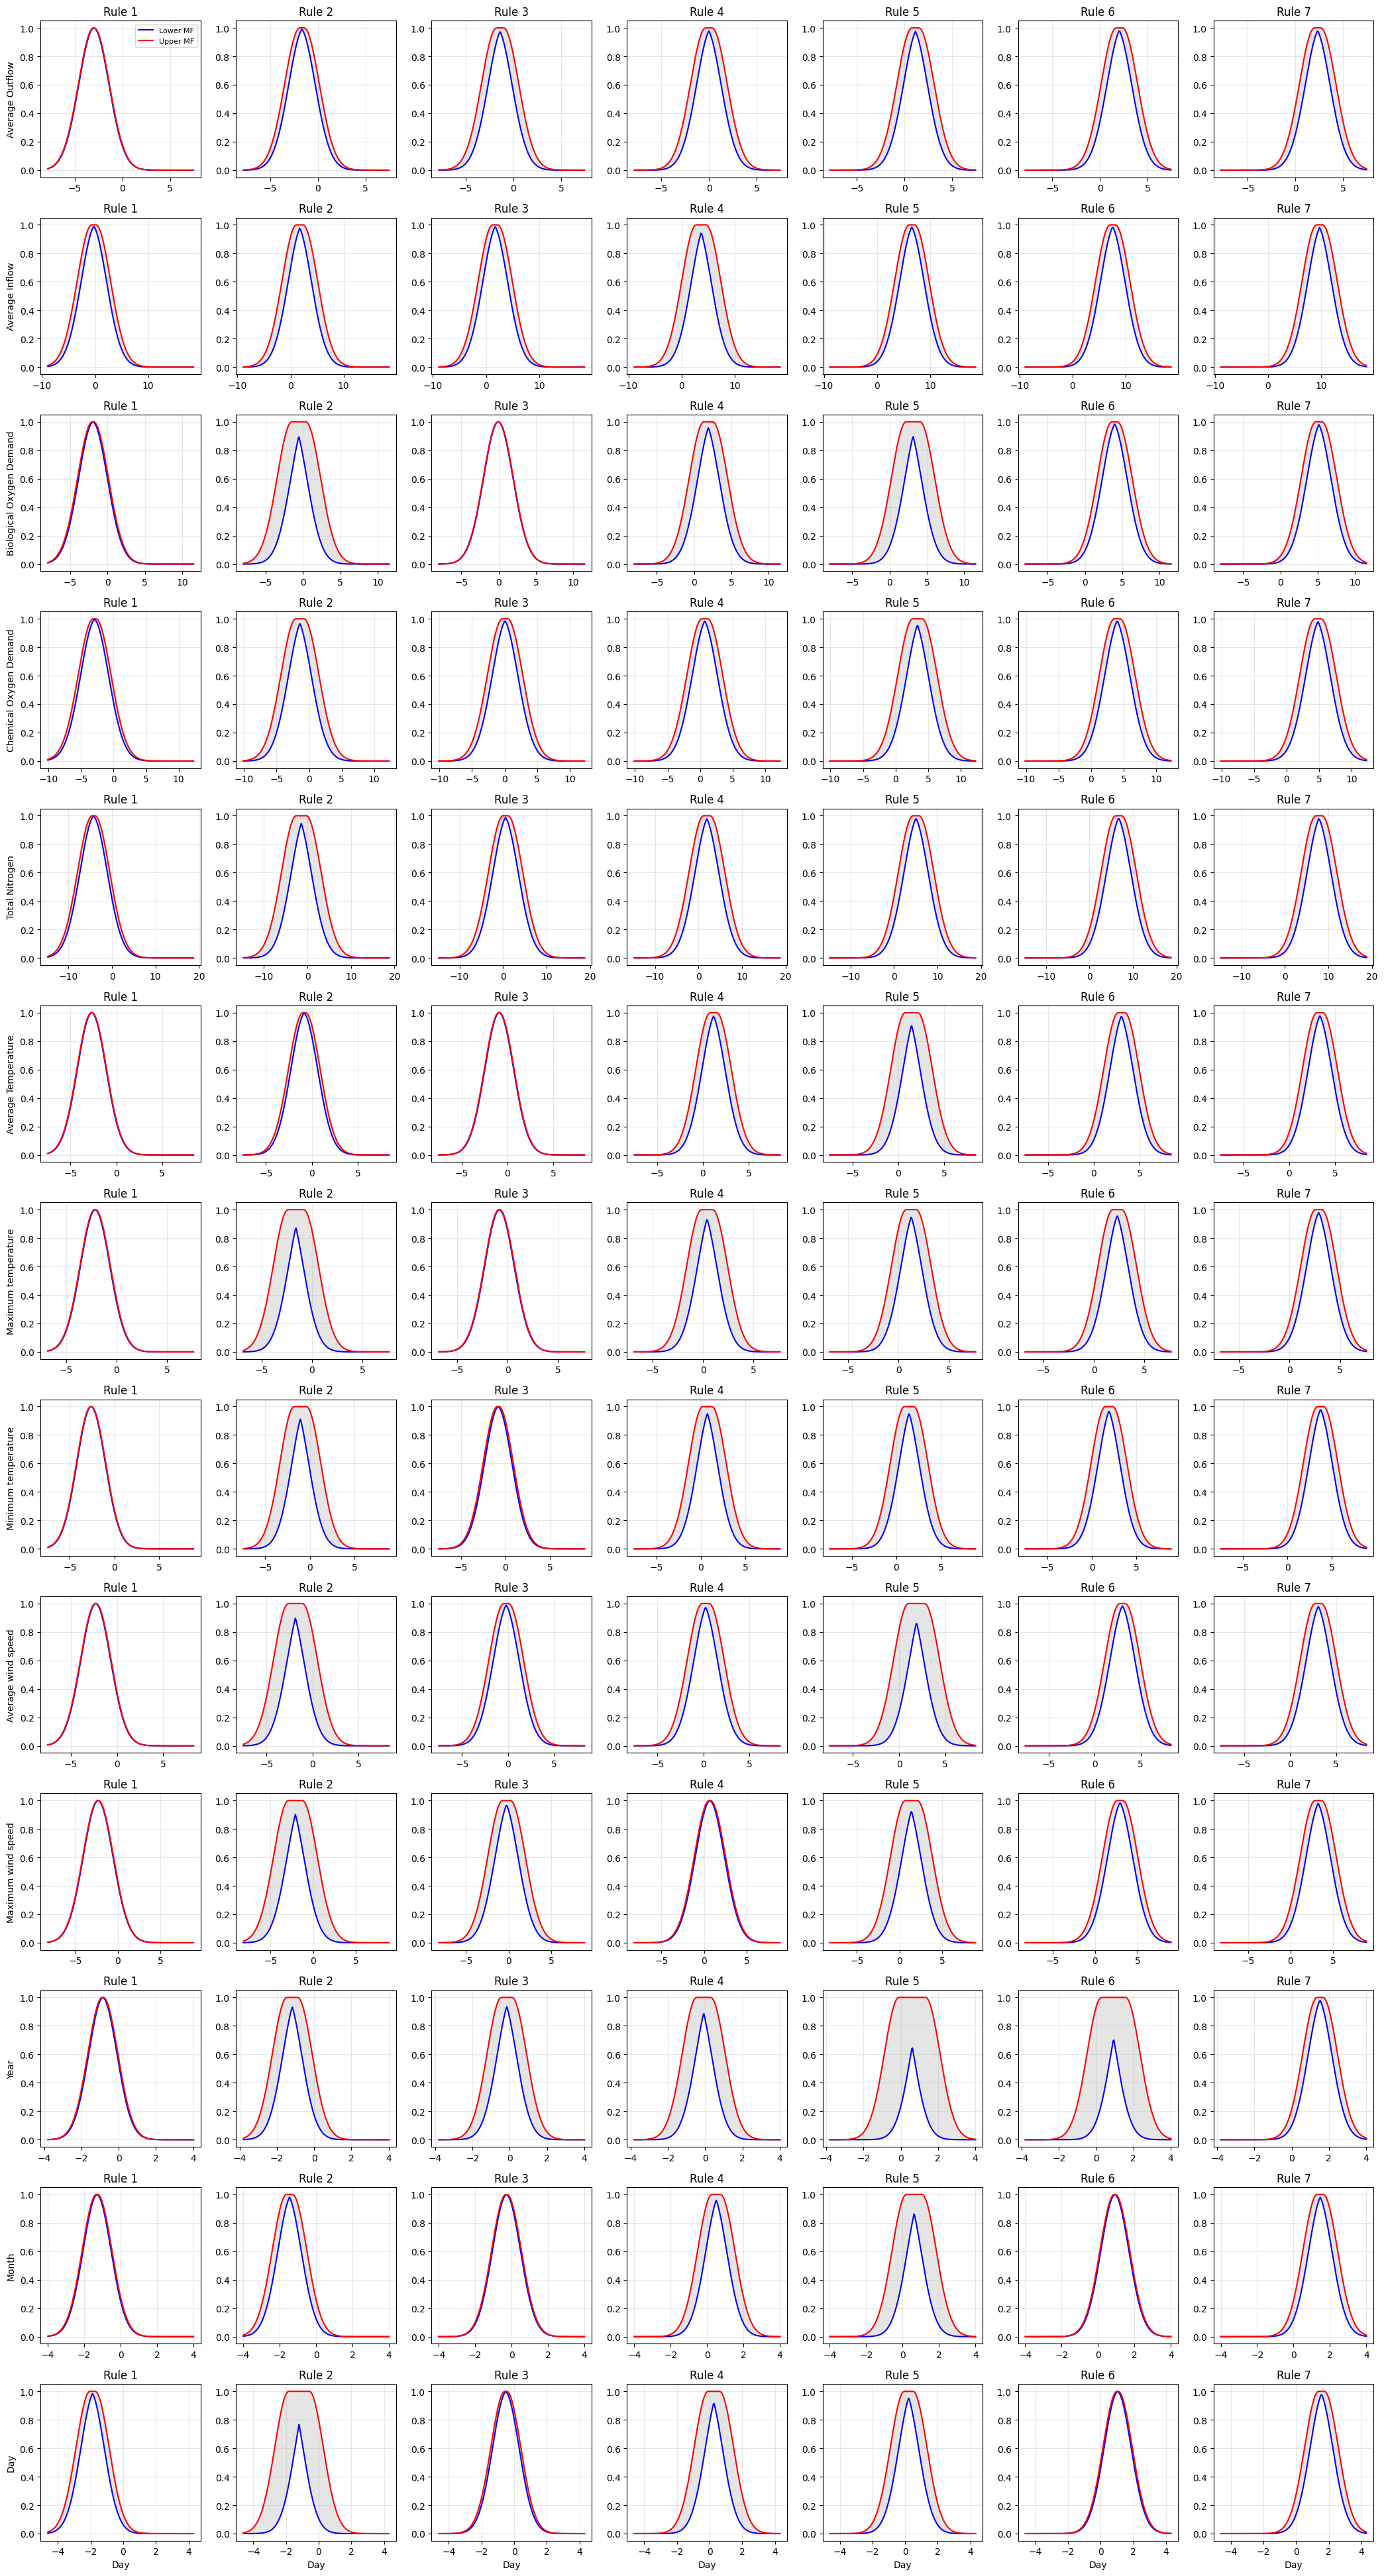

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_membership_functions(model, feature_names=None, n_points=200):
    """
    Plots Interval Type-2 Gaussian membership functions for each feature and rule.
    
    Parameters
    ----------
    model : IT2_TSK_ANFIS
        Trained model.
    feature_names : list of str, optional
        Names of features. Default uses Feature 0, Feature 1, etc.
    n_points : int
        Number of points for MF curves.
    """
    n_features = model.n_features
    n_rules = model.n_rules
    
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(n_features)]
    
    fig, axes = plt.subplots(n_features, n_rules, figsize=(3*n_rules, 3*n_features), sharey=False)
    
    # Ensure axes is 2D array even if n_features or n_rules == 1
    if n_features == 1:
        axes = axes[np.newaxis, :]
    if n_rules == 1:
        axes = axes[:, np.newaxis]
    
    for f_idx in range(n_features):
        # Create range for this feature
        x_min = np.min(model.c1[:, f_idx] - 3*model.stds[:, f_idx])
        x_max = np.max(model.c2[:, f_idx] + 3*model.stds[:, f_idx])
        x_vals = np.linspace(x_min, x_max, n_points)
        
        for r_idx in range(n_rules):
            c1 = model.c1[r_idx, f_idx]
            c2 = model.c2[r_idx, f_idx]
            sigma = model.stds[r_idx, f_idx]
            
            # Compute lower MF
            c_mid = 0.5*(c1+c2)
            mu_lower = np.where(x_vals <= c_mid,
                                np.exp(-0.5*((x_vals - c2)/sigma)**2),
                                np.exp(-0.5*((x_vals - c1)/sigma)**2))
            
            # Compute upper MF
            mu_upper = np.where(x_vals < c1,
                                np.exp(-0.5*((x_vals - c1)/sigma)**2),
                                np.where(x_vals <= c2,
                                         1.0,
                                         np.exp(-0.5*((x_vals - c2)/sigma)**2)))
            
            ax = axes[f_idx, r_idx]
            ax.plot(x_vals, mu_lower, 'b', label='Lower MF')
            ax.plot(x_vals, mu_upper, 'r', label='Upper MF')
            ax.fill_between(x_vals, mu_lower, mu_upper, color='gray', alpha=0.2)
            ax.set_title(f'Rule {r_idx+1}')
            ax.set_ylim(-0.05, 1.05)
            if f_idx == n_features-1:
                ax.set_xlabel(feature_names[f_idx])
            if r_idx == 0:
                ax.set_ylabel(feature_names[f_idx])
            ax.grid(True, alpha=0.3)
            if f_idx == 0 and r_idx == 0:
                ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Example usage:
feature_names = df_final.drop(columns=['Energy Consumption (MWh)']).columns.tolist()
plot_membership_functions(model, feature_names=feature_names)

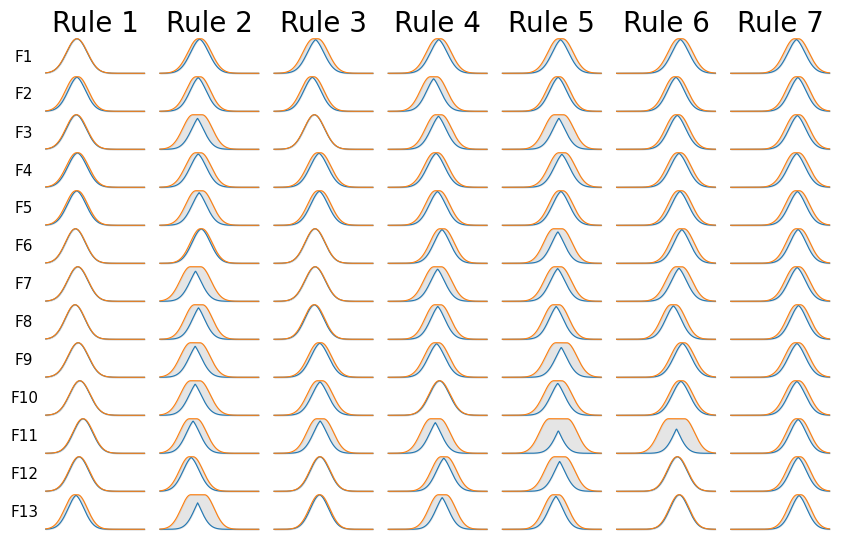

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_membership_functions_compact_no_ticks(model, n_points=200,
                                               label_fontsize=11, tick_labelsize=8,
                                               rule_title_fontsize=20, 
                                               compressed_width_factor=1.2,
                                               compressed_height_factor=0.4, 
                                               wspace=0.05):
    """
    Compact, paper-ready plot of Interval Type-2 Gaussian membership functions.
    Y-axis labeled F1..Fn, no x-axis labels, no ticks anywhere, no boxes.
    """

    n_features = model.n_features
    n_rules = model.n_rules

    # Rename features as F1, F2, ..., Fn
    feature_names = [f'F{i+1}' for i in range(n_features)]

    # Highly compact layout
    fig_width = max(3.0, n_rules * compressed_width_factor)
    fig_height = max(2.0, n_features * compressed_height_factor)
    fig, axes = plt.subplots(n_features, n_rules, figsize=(fig_width, fig_height),
                             squeeze=False)

    plt.subplots_adjust(hspace=0.0, wspace=wspace, left=0.05, right=0.995, top=0.98, bottom=0.03)

    for f_idx in range(n_features):
        x_min = np.min(model.c1[:, f_idx] - 3 * model.stds[:, f_idx])
        x_max = np.max(model.c2[:, f_idx] + 3 * model.stds[:, f_idx])
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max == x_min:
            mid = np.mean(np.hstack([model.c1[:, f_idx], model.c2[:, f_idx]]))
            x_min, x_max = mid - 1.0, mid + 1.0

        x_vals = np.linspace(x_min, x_max, n_points)

        for r_idx in range(n_rules):
            c1 = model.c1[r_idx, f_idx]
            c2 = model.c2[r_idx, f_idx]
            sigma = model.stds[r_idx, f_idx]

            c_mid = 0.5 * (c1 + c2)
            mu_lower = np.where(x_vals <= c_mid,
                                np.exp(-0.5 * ((x_vals - c2) / sigma) ** 2),
                                np.exp(-0.5 * ((x_vals - c1) / sigma) ** 2))

            mu_upper = np.where(x_vals < c1,
                                np.exp(-0.5 * ((x_vals - c1) / sigma) ** 2),
                                np.where(x_vals <= c2,
                                         1.0,
                                         np.exp(-0.5 * ((x_vals - c2) / sigma) ** 2)))

            ax = axes[f_idx, r_idx]

            ax.plot(x_vals, mu_lower, linewidth=0.8)
            ax.plot(x_vals, mu_upper, linewidth=0.8)
            ax.fill_between(x_vals, mu_lower, mu_upper, color='gray', alpha=0.2)
            ax.set_ylim(-0.05, 1.05)

            # Column titles only on row 0
            if f_idx == 0:
                ax.set_title(f'Rule {r_idx + 1}', fontsize=rule_title_fontsize, pad=4)

            # Y-axis labels only in first column
            if r_idx == 0:
                ax.set_ylabel(feature_names[f_idx], fontsize=label_fontsize, rotation=0,
                              labelpad=12, va='center')
            else:
                ax.set_ylabel('')

            # REMOVE all x-axis labels and ticks
            ax.set_xlabel('')
            ax.set_xticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])

            # REMOVE all spines for every subplot
            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.4)

            # Legend only on (0,0)
            if f_idx == 0 and r_idx == 0:
                ax.plot([], [], 'b', label='Lower MF', linewidth=0.8)
                ax.plot([], [], 'r', label='Upper MF', linewidth=0.8)

    plt.show()


# =======================================
# CALLING EXAMPLE
# =======================================
plot_membership_functions_compact_no_ticks(model)

### another plot for the paper visualizing only Biological Oxygen Demand, Average wind speed, Average outflow

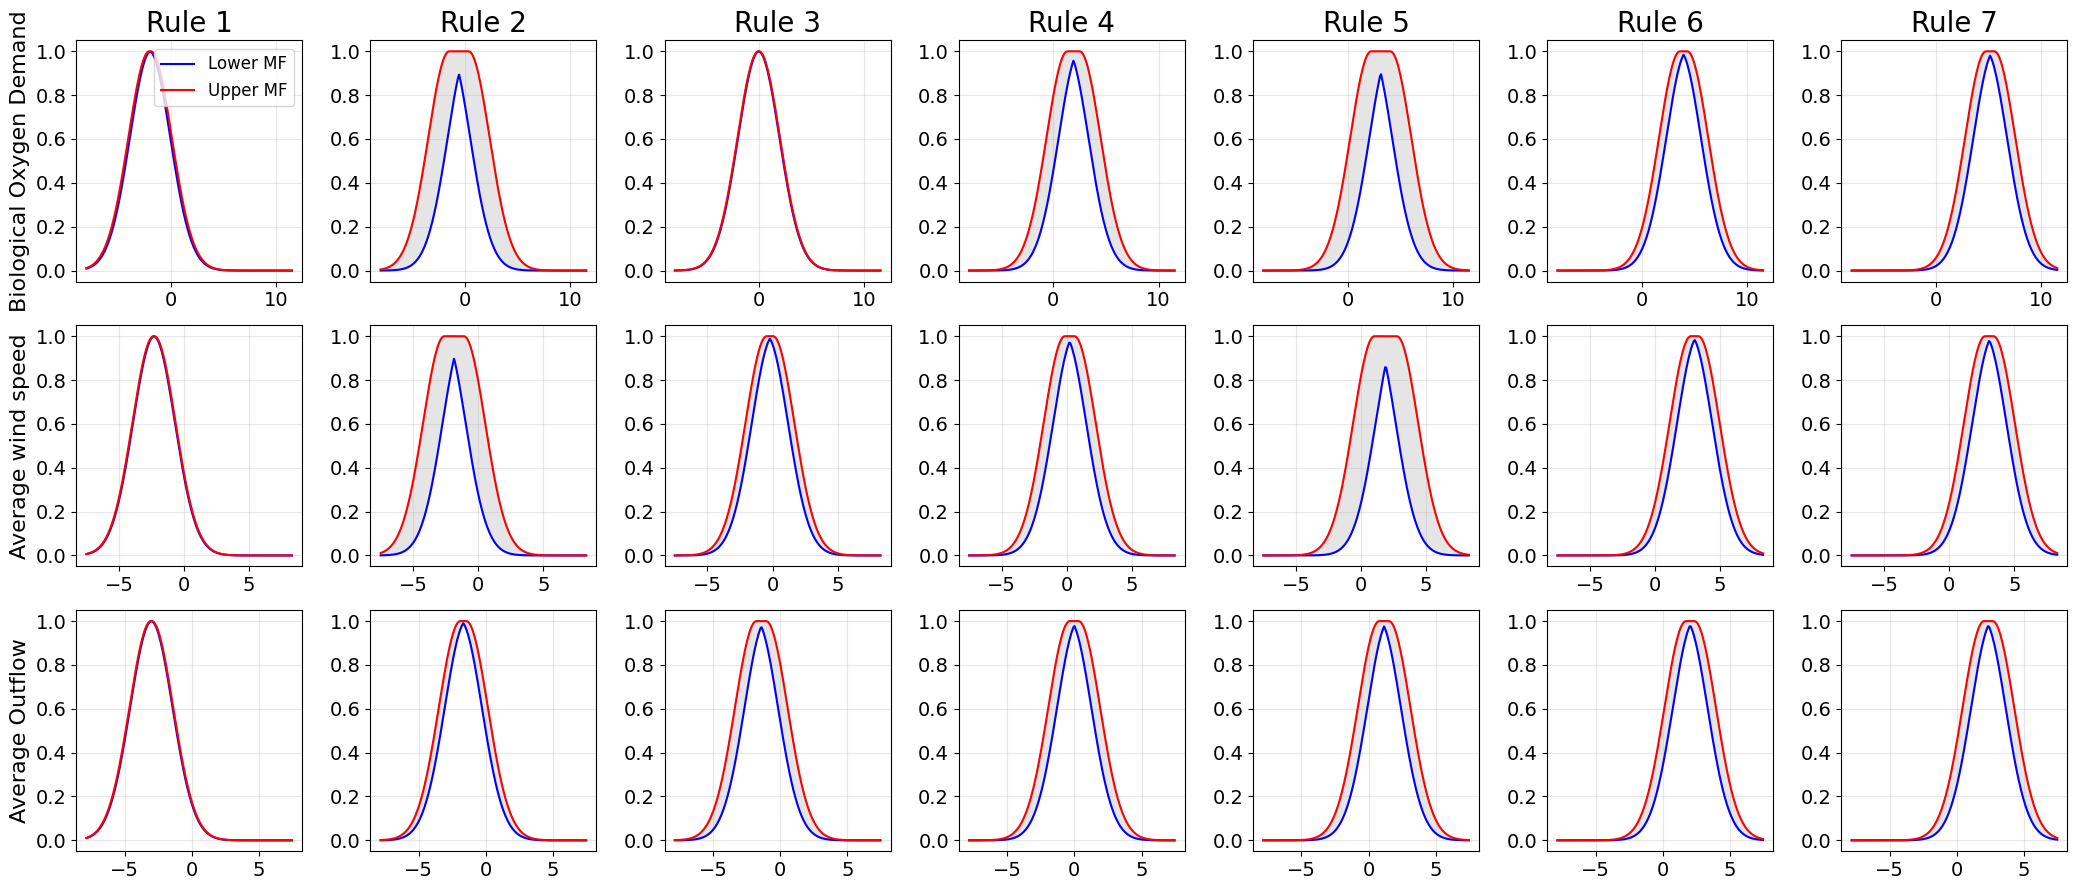

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_selected_membership_functions(model, feature_names, selected_features, n_points=200):
    """
    Plots Interval Type-2 Gaussian membership functions for selected features
    with increased tick size and improved readability.
    """
    n_rules = model.n_rules
    
    # Indices of selected features
    selected_indices = [feature_names.index(f) for f in selected_features if f in feature_names]
    n_features = len(selected_indices)
    
    fig, axes = plt.subplots(n_features, n_rules, figsize=(3*n_rules, 3*n_features), sharey=False)
    
    # Ensure axes is 2D array even if single feature/rule
    if n_features == 1:
        axes = axes[np.newaxis, :]
    if n_rules == 1:
        axes = axes[:, np.newaxis]
    
    for idx, f_idx in enumerate(selected_indices):
        # Range for this feature
        x_min = np.min(model.c1[:, f_idx] - 3*model.stds[:, f_idx])
        x_max = np.max(model.c2[:, f_idx] + 3*model.stds[:, f_idx])
        x_vals = np.linspace(x_min, x_max, n_points)
        
        for r_idx in range(n_rules):
            c1 = model.c1[r_idx, f_idx]
            c2 = model.c2[r_idx, f_idx]
            sigma = model.stds[r_idx, f_idx]
            
            # Lower MF
            c_mid = 0.5*(c1+c2)
            mu_lower = np.where(x_vals <= c_mid,
                                np.exp(-0.5*((x_vals - c2)/sigma)**2),
                                np.exp(-0.5*((x_vals - c1)/sigma)**2))
            
            # Upper MF
            mu_upper = np.where(x_vals < c1,
                                np.exp(-0.5*((x_vals - c1)/sigma)**2),
                                np.where(x_vals <= c2,
                                         1.0,
                                         np.exp(-0.5*((x_vals - c2)/sigma)**2)))
            
            ax = axes[idx, r_idx]
            ax.plot(x_vals, mu_lower, 'b', label='Lower MF')
            ax.plot(x_vals, mu_upper, 'r', label='Upper MF')
            ax.fill_between(x_vals, mu_lower, mu_upper, color='gray', alpha=0.2)
            
            # ---- Customizations ----
            # Show titles for the first row
            if idx == 0:
                ax.set_title(f'Rule {r_idx+1}', fontsize=20)
            
            ax.set_ylim(-0.05, 1.05)
            
            # X-axis tick labels
            if idx < 2 or idx == n_features-1:
                ax.tick_params(axis='x', labelbottom=True, labelsize=14)  # Increased tick size
            else:
                ax.tick_params(axis='x', labelbottom=False)
            
            # Y-axis tick labels
            ax.tick_params(axis='y', labelsize=14)  # Increased tick size
            
            # Remove x-axis label for the last row
            if idx == n_features-1:
                ax.set_xlabel("")
            
            # Y-axis label with larger font size (only first column)
            if r_idx == 0:
                ax.set_ylabel(feature_names[f_idx], fontsize=16)
            
            ax.grid(True, alpha=0.3)
            # Show legend only on the top-left plot
            if idx == 0 and r_idx == 0:
                ax.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()


# -------- Example usage --------
all_feature_names = df_final.drop(columns=['Energy Consumption (MWh)']).columns.tolist()
selected = ["Biological Oxygen Demand", "Average wind speed", "Average Outflow"]

plot_selected_membership_functions(model, feature_names=all_feature_names, selected_features=selected)

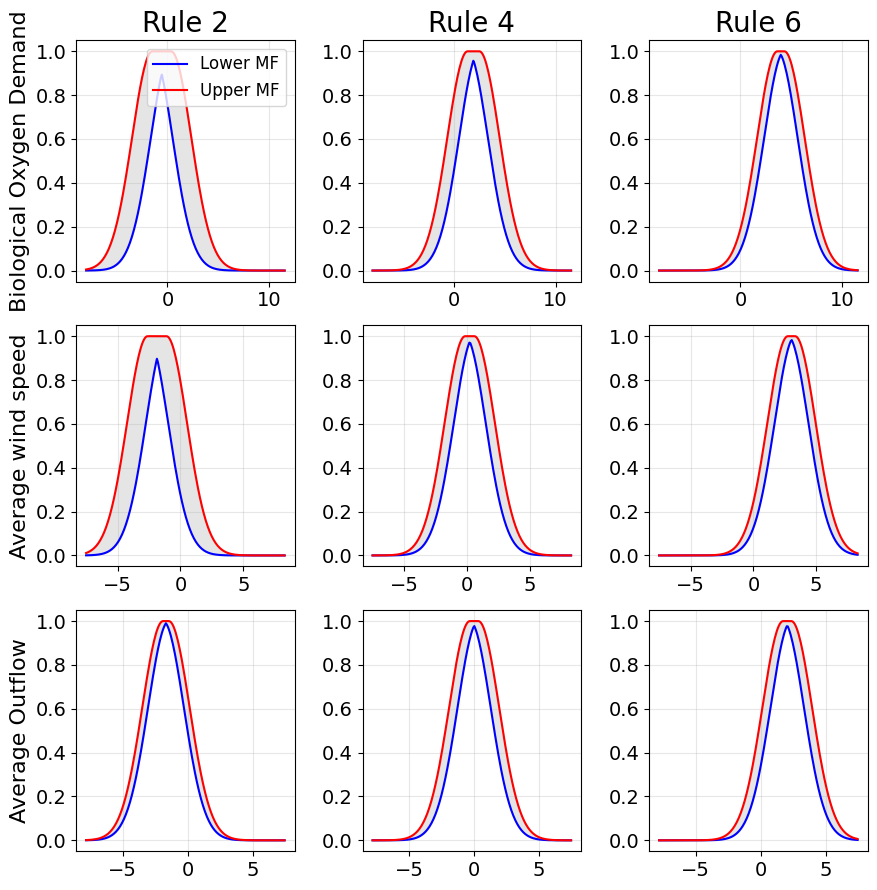

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_selected_membership_functions(model, feature_names, selected_features, selected_rules=[2,4,6,8], n_points=200):
    """
    Plots Interval Type-2 Gaussian membership functions for selected features
    and selected rules with increased tick size and improved readability.
    """
    n_rules = model.n_rules
    
    # Indices of selected features
    selected_indices = [feature_names.index(f) for f in selected_features if f in feature_names]
    n_features = len(selected_indices)
    
    # Adjust rule indices to 0-based
    selected_rule_indices = [r-1 for r in selected_rules if 1 <= r <= n_rules]
    n_selected_rules = len(selected_rule_indices)
    
    fig, axes = plt.subplots(n_features, n_selected_rules, figsize=(3*n_selected_rules, 3*n_features), sharey=False)
    
    # Ensure axes is 2D array even if single feature/rule
    if n_features == 1:
        axes = axes[np.newaxis, :]
    if n_selected_rules == 1:
        axes = axes[:, np.newaxis]
    
    for idx, f_idx in enumerate(selected_indices):
        # Range for this feature
        x_min = np.min(model.c1[:, f_idx] - 3*model.stds[:, f_idx])
        x_max = np.max(model.c2[:, f_idx] + 3*model.stds[:, f_idx])
        x_vals = np.linspace(x_min, x_max, n_points)
        
        for ax_idx, r_idx in enumerate(selected_rule_indices):
            c1 = model.c1[r_idx, f_idx]
            c2 = model.c2[r_idx, f_idx]
            sigma = model.stds[r_idx, f_idx]
            
            # Lower MF
            c_mid = 0.5*(c1+c2)
            mu_lower = np.where(x_vals <= c_mid,
                                np.exp(-0.5*((x_vals - c2)/sigma)**2),
                                np.exp(-0.5*((x_vals - c1)/sigma)**2))
            
            # Upper MF
            mu_upper = np.where(x_vals < c1,
                                np.exp(-0.5*((x_vals - c1)/sigma)**2),
                                np.where(x_vals <= c2,
                                         1.0,
                                         np.exp(-0.5*((x_vals - c2)/sigma)**2)))
            
            ax = axes[idx, ax_idx]
            ax.plot(x_vals, mu_lower, 'b', label='Lower MF')
            ax.plot(x_vals, mu_upper, 'r', label='Upper MF')
            ax.fill_between(x_vals, mu_lower, mu_upper, color='gray', alpha=0.2)
            
            # ---- Customizations ----
            if idx == 0:
                ax.set_title(f'Rule {r_idx+1}', fontsize=20)
            
            ax.set_ylim(-0.05, 1.05)
            
            ax.tick_params(axis='x', labelbottom=True, labelsize=14)
            ax.tick_params(axis='y', labelsize=14)
            
            if idx == n_features-1:
                ax.set_xlabel("")
            
            if ax_idx == 0:
                ax.set_ylabel(feature_names[f_idx], fontsize=16)
            
            ax.grid(True, alpha=0.3)
            if idx == 0 and ax_idx == 0:
                ax.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()


# -------- Example usage --------
all_feature_names = df_final.drop(columns=['Energy Consumption (MWh)']).columns.tolist()
selected = ["Biological Oxygen Demand", "Average wind speed", "Average Outflow"]

plot_selected_membership_functions(model, feature_names=all_feature_names, selected_features=selected)

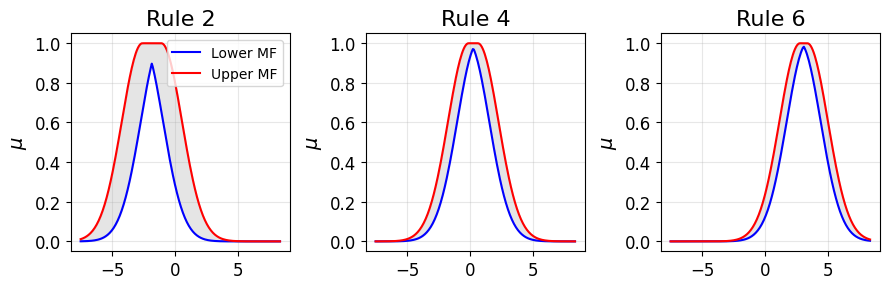

In [43]:
def plot_second_row_membership_functions(model, feature_names, selected_features, selected_rules=[2,4,6,8], n_points=200):
    """
    Plots only the subplots in the second row of selected features.
    The y-axis label is replaced with the symbol 'μ' for membership functions.
    """
    n_rules = model.n_rules
    
    # Indices of selected features
    selected_indices = [feature_names.index(f) for f in selected_features if f in feature_names]
    
    if len(selected_indices) < 2:
        raise ValueError("Need at least two selected features to have a 'second row'.")
    
    # Only keep the second feature (second row)
    idx = 1
    f_idx = selected_indices[idx]
    
    # Adjust rule indices to 0-based
    selected_rule_indices = [r-1 for r in selected_rules if 1 <= r <= n_rules]
    n_selected_rules = len(selected_rule_indices)
    
    fig, axes = plt.subplots(1, n_selected_rules, figsize=(3*n_selected_rules, 3), sharey=False)
    if n_selected_rules == 1:
        axes = np.array([axes])
    
    # Range for this feature
    x_min = np.min(model.c1[:, f_idx] - 3*model.stds[:, f_idx])
    x_max = np.max(model.c2[:, f_idx] + 3*model.stds[:, f_idx])
    x_vals = np.linspace(x_min, x_max, n_points)
    
    for ax_idx, r_idx in enumerate(selected_rule_indices):
        c1 = model.c1[r_idx, f_idx]
        c2 = model.c2[r_idx, f_idx]
        sigma = model.stds[r_idx, f_idx]
        
        # Lower MF
        c_mid = 0.5*(c1+c2)
        mu_lower = np.where(x_vals <= c_mid,
                            np.exp(-0.5*((x_vals - c2)/sigma)**2),
                            np.exp(-0.5*((x_vals - c1)/sigma)**2))
        
        # Upper MF
        mu_upper = np.where(x_vals < c1,
                            np.exp(-0.5*((x_vals - c1)/sigma)**2),
                            np.where(x_vals <= c2,
                                     1.0,
                                     np.exp(-0.5*((x_vals - c2)/sigma)**2)))
        
        ax = axes[ax_idx]
        ax.plot(x_vals, mu_lower, 'b', label='Lower MF')
        ax.plot(x_vals, mu_upper, 'r', label='Upper MF')
        ax.fill_between(x_vals, mu_lower, mu_upper, color='gray', alpha=0.2)
        
        ax.set_title(f'Rule {r_idx+1}', fontsize=16)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylabel(r'$\mu$', fontsize=14)  # <-- y-axis label is now μ
        ax.grid(True, alpha=0.3)
        if ax_idx == 0:
            ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_second_row_membership_functions(model, feature_names=all_feature_names, selected_features=selected)

## the end